Accuracy: 0.9525
Precision: 0.9627906976744186
Recall: 0.9838403041825095


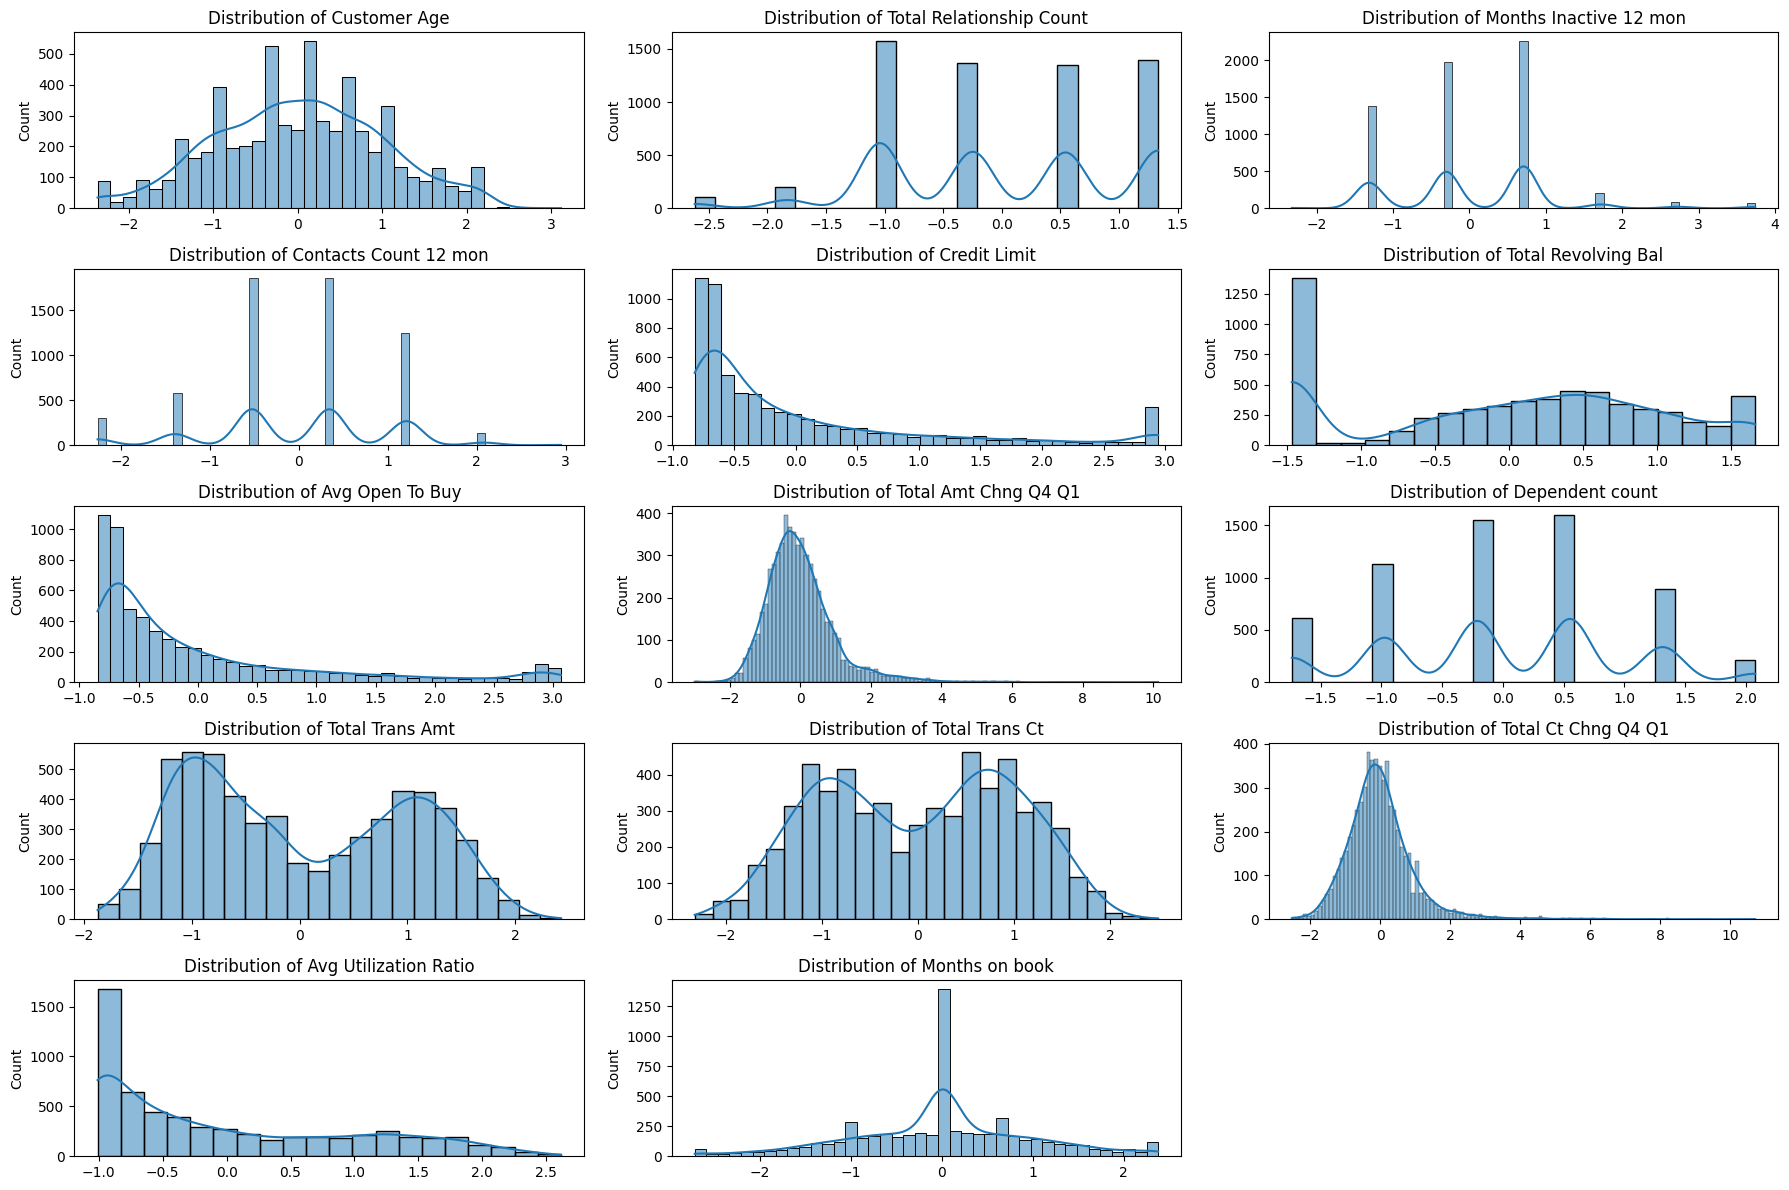

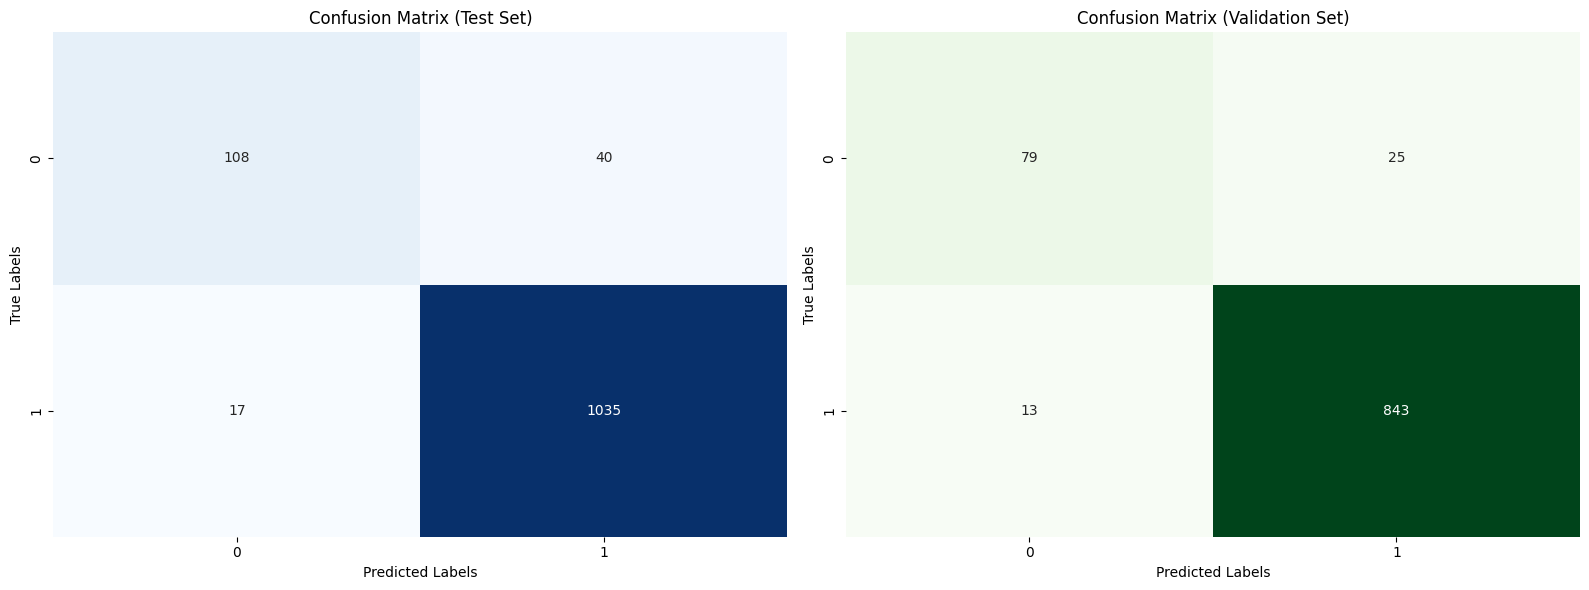

Classification Report:
                    precision    recall  f1-score   support

Attrited Customer       0.86      0.73      0.79       148
Existing Customer       0.96      0.98      0.97      1052

         accuracy                           0.95      1200
        macro avg       0.91      0.86      0.88      1200
     weighted avg       0.95      0.95      0.95      1200



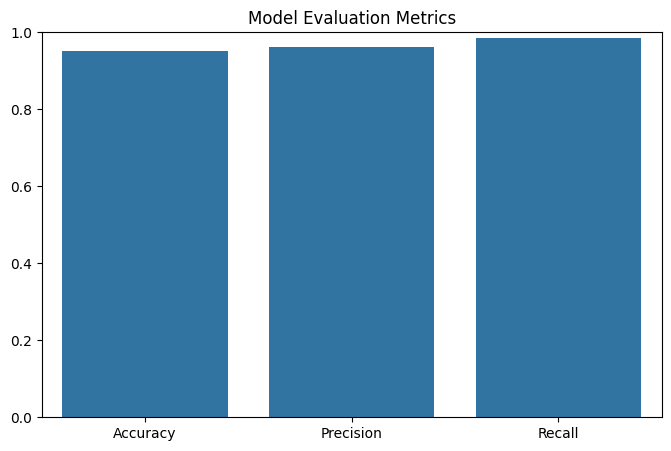

Number of Matches: 100
Number of Mismatches: 0
Percentage of Correct Classification: 100.00%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/BankChurners for EDA 2024.csv')

# Define specific attributes to include
selected_attributes = ['Gender', 'Education Level', 'Marital Status', 'Income Category', 'Card Category', 'Customer Age', 'Total Relationship Count', 'Months Inactive 12 mon',
                       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
                       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Dependent count', 'Total Trans Amt',
                       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio',
                       'Months on book']

# Filter the DataFrame to include only selected attributes
X = data[selected_attributes]
y = data['Attrition Flag']

# Identify categorical and numerical columns
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]

# Preprocessing for numerical data (imputation and scaling)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (not needed as we only have numerical attributes)

# Bundle preprocessing for numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols)
    ])

# Define the model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing and model training in one pipeline
pipeline.fit(X_train, y_train)

# Predict on the testing set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Existing Customer')
recall = recall_score(y_test, y_pred, pos_label='Existing Customer')

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Data Visualization
# Load the cleaned data after preprocessing
X_cleaned = preprocessor.transform(X)

# Create DataFrame for cleaned data
data_cleaned = pd.DataFrame(X_cleaned, columns=numerical_cols)

# Plotting distributions of numerical features
num_numerical_cols = len(numerical_cols)
num_rows = (num_numerical_cols // 3) + 1  # Calculate number of rows needed based on numerical column count
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(data_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix

# Calculate confusion matrix for the test set
cm_test = confusion_matrix(y_test, y_pred)

# Evaluate on the validation set (using a portion of the training data)
X_train_partial, X_valid, y_train_partial, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Preprocessing and model training on the partial training set
pipeline.fit(X_train_partial, y_train_partial)

# Predict on the validation set
y_pred_valid = pipeline.predict(X_valid)

# Calculate confusion matrix for the validation set
cm_valid = confusion_matrix(y_valid, y_pred_valid)

# Plot confusion matrices
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.subplot(1, 2, 2)
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report

# Assuming y_test and y_pred are already defined
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Existing Customer')
recall = recall_score(y_test, y_pred, pos_label='Existing Customer')

# Plotting evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall']
scores = [accuracy, precision, recall]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=scores)
plt.ylim(0, 1.0)  # Set y-axis limits for scores
plt.title('Model Evaluation Metrics')
plt.show()

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

# Load the dataset (replace 'BankChurners.csv' with your dataset file)
data = pd.read_csv('/content/drive/MyDrive/BankChurners for EDA 2024.csv')
# Define target variable and predictor variables
target = 'Attrition Flag'
categorical_cols = ['Gender', 'Education Level', 'Marital Status', 'Income Category', 'Card Category']
numerical_cols = [col for col in data.columns if col != target and col not in categorical_cols]

# Convert categorical variables to one-hot encoding
data_processed = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Split the dataset into training and testing sets
X = data_processed.drop(target, axis=1)
y = data_processed[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Select 100 records randomly from the training set
sample_size = 100
training_sample_indices = X_train.sample(n=sample_size, random_state=42).index

# Get the subset of records and corresponding true labels
sample_X = X_train.loc[training_sample_indices]
sample_y_true = y_train.loc[training_sample_indices]

# Get predictions for the selected subset
sample_y_pred = rf_model.predict(sample_X)

# Compare true labels (sample_y_true) with predictions (sample_y_pred)
matches = (sample_y_true == sample_y_pred).sum()
mismatches = (sample_y_true != sample_y_pred).sum()  # Calculate mismatches correctly


# Calculate percentage of correct classification
percentage_correct = (matches / sample_size) * 100

# Print results
print(f"Number of Matches: {matches}")
print(f"Number of Mismatches: {mismatches}")
print(f"Percentage of Correct Classification: {percentage_correct:.2f}%")

In [16]:
#Import all Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#Read dataset
df = pd.read_csv('/content/drive/MyDrive/BankChurners for EDA 2024.csv')
print(df)

      CLIENTNUM     Attrition Flag  Customer Age Gender  Dependent count  \
0     717965808  Existing Customer            65      M                0   
1     716298633  Existing Customer            56      F                1   
2     782548758  Existing Customer            42      F                5   
3     826410708  Existing Customer            40      M                4   
4     715276683  Existing Customer            52      M                2   
...         ...                ...           ...    ...              ...   
5993  803595858  Attrited Customer            56      F                3   
5994  710899833  Attrited Customer            36      M                2   
5995  709537683  Attrited Customer            37      M                3   
5996  767712558  Attrited Customer            59      M                1   
5997  708874533  Attrited Customer            45      F                2   

     Education Level Marital Status Income Category Card Category  \
0            Unkno

In [19]:
#show the first 5 rows using dataframe.head() method
df.head(10)

,CLIENTNUM,Attrition Flag,Customer Age,Gender,Dependent count,Education Level,Marital Status,Income Category,Card Category,Months on book,...,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
0,717965808,Existing Customer,65,M,0,Unknown,Single,$40K - $60K,Blue,54,...,1,4,9383.0,829,8554.0,0.515,5783,73,0.622,0.088
1,716298633,Existing Customer,56,F,1,Graduate,Single,Less than $40K,Blue,47,...,2,3,2086.0,1792,294.0,0.859,5774,84,0.909,0.859
2,782548758,Existing Customer,42,F,5,High School,Divorced,Less than $40K,Blue,36,...,2,3,2069.0,1288,781.0,0.810,5668,82,0.640,0.623
3,826410708,Existing Customer,40,M,4,Unknown,Married,$60K - $80K,Blue,36,...,2,3,22956.0,1407,21549.0,0.709,5554,64,0.600,0.061
4,715276683,Existing Customer,52,M,2,High School,Married,$60K - $80K,Blue,45,...,1,4,24287.0,1676,22611.0,0.506,5495,69,0.816,0.069
5,717626508,Existing Customer,44,F,3,Graduate,Married,Less than $40K,Blue,36,...,3,1,1699.0,0,1699.0,0.653,5495,87,0.642,0.000
6,716483358,Existing Customer,44,M,3,Graduate,Single,$40K - $60K,Blue,29,...,1,4,6125.0,1329,4796.0,0.646,5481,68,0.700,0.217
7,713447583,Existing Customer,48,F,3,High School,Single,$40K - $60K,Blue,36,...,3,2,3871.0,2055,1816.0,0.824,5480,58,0.933,0.531
8,714738033,Existing Customer,44,F,4,Graduate,Married,Less than $40K,Blue,25,...,3,2,1602.0,1044,558.0,0.781,5428,85,0.635,0.652
9,709781208,Existing Customer,34,F,0,Unknown,Married,Less than $40K,Blue,26,...,3,1,2291.0,0,2291.0,0.892,5409,82,0.822,0.000


In [20]:
#data types
df.dtypes

CLIENTNUM                     int64
Attrition Flag               object
Customer Age                  int64
Gender                       object
Dependent count               int64
Education Level              object
Marital Status               object
Income Category              object
Card Category                object
Months on book                int64
Total Relationship Count      int64
Months Inactive 12 mon        int64
Contacts Count 12 mon         int64
Credit Limit                float64
Total Revolving Bal           int64
Avg Open To Buy             float64
Total Amt Chng Q4 Q1        float64
Total Trans Amt               int64
Total Trans Ct                int64
Total Ct Chng Q4 Q1         float64
Avg Utilization Ratio       float64
dtype: object

In [21]:
#by using dataframe.describe() you will get static summary of each column
df.describe()

,CLIENTNUM,Customer Age,Dependent count,Months on book,Total Relationship Count,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
count,5.998000e+03,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000
mean,7.397950e+08,46.376792,2.277593,35.981661,4.309770,2.299266,2.608369,8713.911170,1183.529343,7530.381827,0.773616,2816.365288,54.791264,0.706544,0.275964
std,3.724549e+07,8.518824,1.306390,8.397118,1.270124,0.991023,1.151306,8814.794611,803.539413,8848.616015,0.255735,1235.218957,19.284071,0.276111,0.274313
min,7.080833e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130958e+08,40.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2644.000000,580.500000,1368.500000,0.613000,1711.250000,38.000000,0.547000,0.035000
50%,7.180554e+08,46.000000,2.000000,36.000000,4.000000,2.000000,3.000000,5013.000000,1300.500000,3782.500000,0.738000,2566.000000,56.000000,0.682000,0.178000
75%,7.783432e+08,52.000000,3.000000,41.000000,5.000000,3.000000,3.000000,11335.000000,1787.750000,10081.000000,0.886000,3988.750000,71.000000,0.821000,0.496000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,5783.000000,103.000000,3.714000,0.999000


In [22]:
#dataframe.describe(include ="all") will show all statistical summary of each column include categorical values
df.describe(include="all")

,CLIENTNUM,Attrition Flag,Customer Age,Gender,Dependent count,Education Level,Marital Status,Income Category,Card Category,Months on book,...,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
count,5.998000e+03,5998,5998.000000,5998,5998.000000,5998,5998,5998,5998,5998.000000,...,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000,5998.000000
unique,NaN,2,NaN,2,NaN,7,4,6,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Existing Customer,NaN,M,NaN,Graduate,Married,Less than $40K,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5212,NaN,3115,NaN,1858,2886,1963,5698,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.397950e+08,NaN,46.376792,NaN,2.277593,NaN,NaN,NaN,NaN,35.981661,...,2.299266,2.608369,8713.911170,1183.529343,7530.381827,0.773616,2816.365288,54.791264,0.706544,0.275964
std,3.724549e+07,NaN,8.518824,NaN,1.306390,NaN,NaN,NaN,NaN,8.397118,...,0.991023,1.151306,8814.794611,803.539413,8848.616015,0.255735,1235.218957,19.284071,0.276111,0.274313
min,7.080833e+08,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,...,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130958e+08,NaN,40.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,...,2.000000,2.000000,2644.000000,580.500000,1368.500000,0.613000,1711.250000,38.000000,0.547000,0.035000
50%,7.180554e+08,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,...,2.000000,3.000000,5013.000000,1300.500000,3782.500000,0.738000,2566.000000,56.000000,0.682000,0.178000
75%,7.783432e+08,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,41.000000,...,3.000000,3.000000,11335.000000,1787.750000,10081.000000,0.886000,3988.750000,71.000000,0.821000,0.496000


In [23]:
#dataframe.info this method prints information about adataframe including the index type and column, non null values and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 5998 non-null   int64  
 1   Attrition Flag            5998 non-null   object 
 2   Customer Age              5998 non-null   int64  
 3   Gender                    5998 non-null   object 
 4   Dependent count           5998 non-null   int64  
 5   Education Level           5998 non-null   object 
 6   Marital Status            5998 non-null   object 
 7   Income Category           5998 non-null   object 
 8   Card Category             5998 non-null   object 
 9   Months on book            5998 non-null   int64  
 10  Total Relationship Count  5998 non-null   int64  
 11  Months Inactive 12 mon    5998 non-null   int64  
 12  Contacts Count 12 mon     5998 non-null   int64  
 13  Credit Limit              5998 non-null   float64
 14  Total Re

In [24]:
#finding missing value
df.isnull().sum()

CLIENTNUM                   0
Attrition Flag              0
Customer Age                0
Gender                      0
Dependent count             0
Education Level             0
Marital Status              0
Income Category             0
Card Category               0
Months on book              0
Total Relationship Count    0
Months Inactive 12 mon      0
Contacts Count 12 mon       0
Credit Limit                0
Total Revolving Bal         0
Avg Open To Buy             0
Total Amt Chng Q4 Q1        0
Total Trans Amt             0
Total Trans Ct              0
Total Ct Chng Q4 Q1         0
Avg Utilization Ratio       0
dtype: int64

In [25]:
#finding percentage of missing values
df.isnull().sum()/df.shape[0] *100

CLIENTNUM                   0.0
Attrition Flag              0.0
Customer Age                0.0
Gender                      0.0
Dependent count             0.0
Education Level             0.0
Marital Status              0.0
Income Category             0.0
Card Category               0.0
Months on book              0.0
Total Relationship Count    0.0
Months Inactive 12 mon      0.0
Contacts Count 12 mon       0.0
Credit Limit                0.0
Total Revolving Bal         0.0
Avg Open To Buy             0.0
Total Amt Chng Q4 Q1        0.0
Total Trans Amt             0.0
Total Trans Ct              0.0
Total Ct Chng Q4 Q1         0.0
Avg Utilization Ratio       0.0
dtype: float64

In [26]:
#finding dupicates
df.duplicated().sum()

0

In [27]:
# identifying garbage values
for i in df.select_dtypes(include = "object").columns:
  print(df[i].value_counts())
  print("***"*10)

Attrition Flag
Existing Customer    5212
Attrited Customer     786
Name: count, dtype: int64
******************************
Gender
M    3115
F    2883
Name: count, dtype: int64
******************************
Education Level
Graduate         1858
High School      1202
Uneducated        894
Unknown           885
College           586
Post-Graduate     294
Doctorate         279
Name: count, dtype: int64
******************************
Marital Status
Married     2886
Single      2274
Divorced     441
Unknown      397
Name: count, dtype: int64
******************************
Income Category
Less than $40K    1963
$40K - $60K       1030
$80K - $120K       993
$60K - $80K        922
Unknown            624
$120K +            466
Name: count, dtype: int64
******************************
Card Category
Blue        5698
Silver       264
Gold          33
Platinum       3
Name: count, dtype: int64
******************************


In [28]:
# descriptive analysis for object variables
df.describe(include = "object")

,Attrition Flag,Gender,Education Level,Marital Status,Income Category,Card Category
count,5998,5998,5998,5998,5998,5998
unique,2,2,7,4,6,4
top,Existing Customer,M,Graduate,Married,Less than $40K,Blue
freq,5212,3115,1858,2886,1963,5698


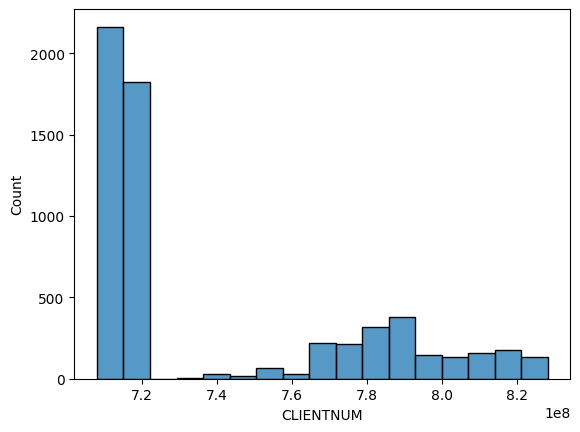

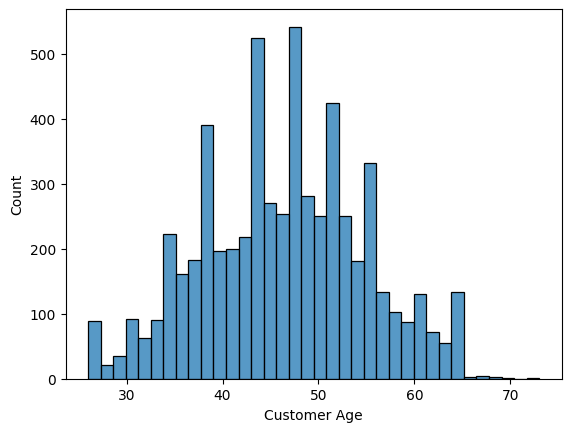

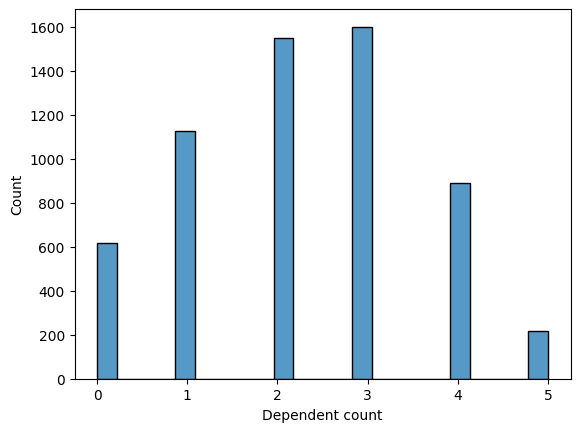

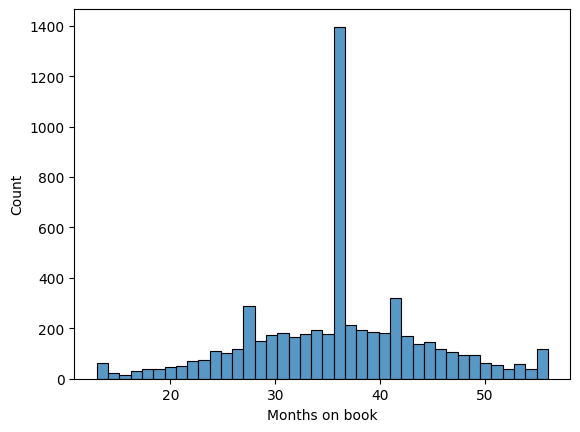

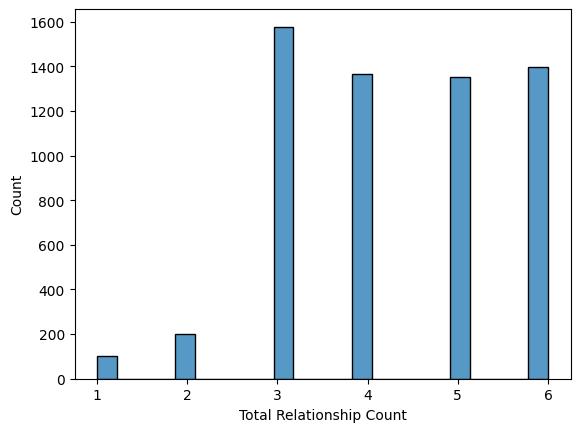

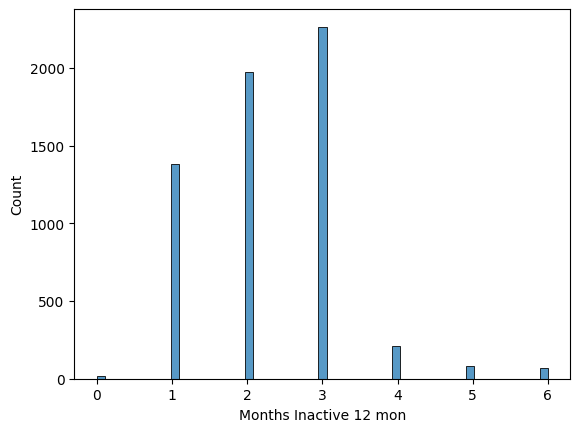

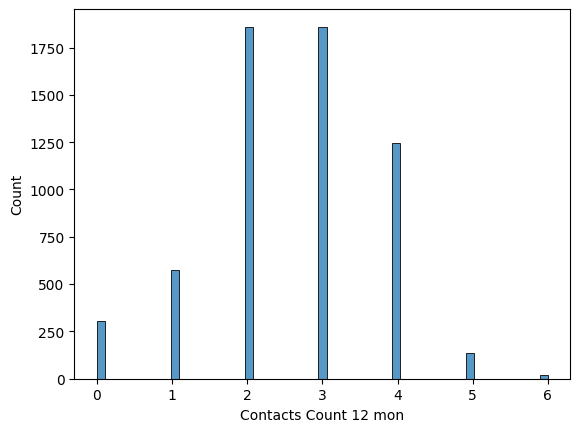

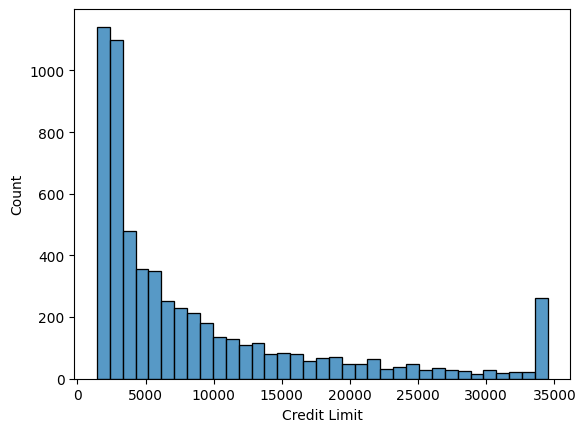

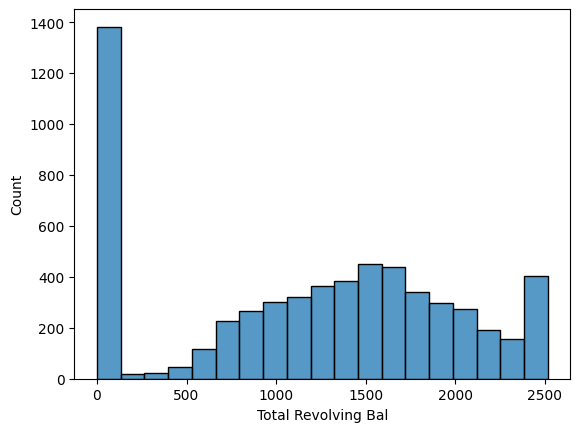

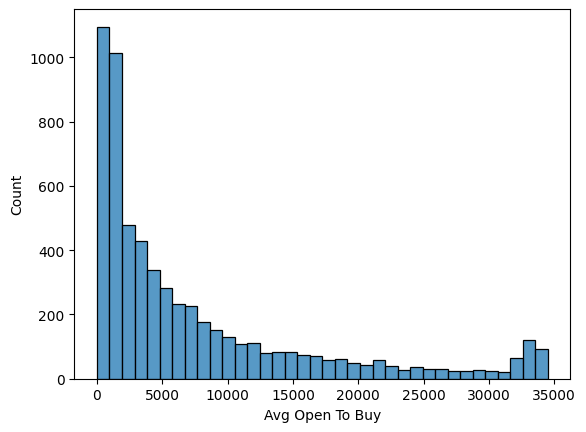

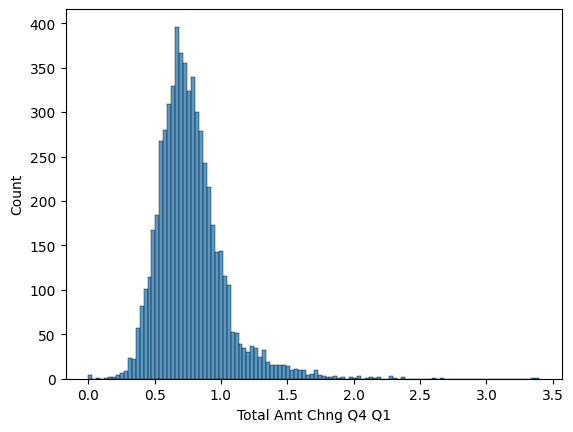

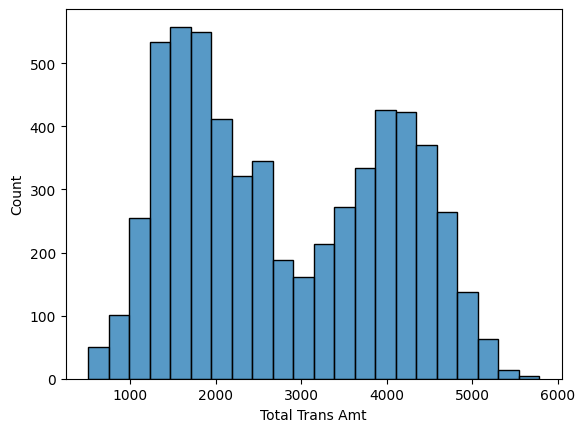

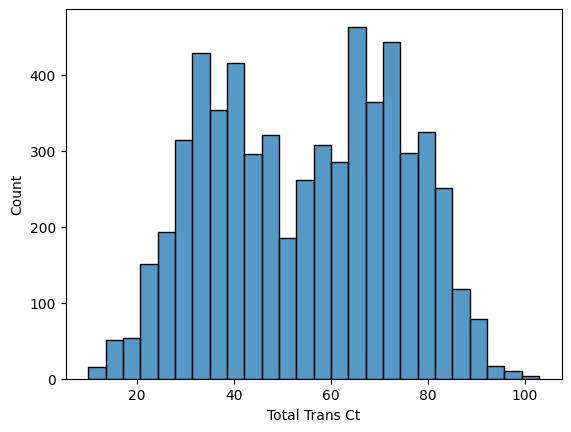

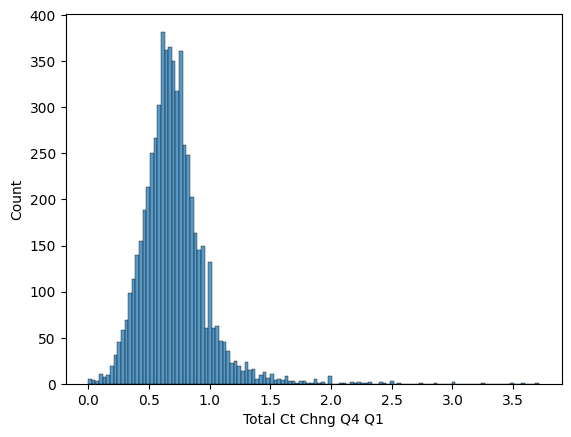

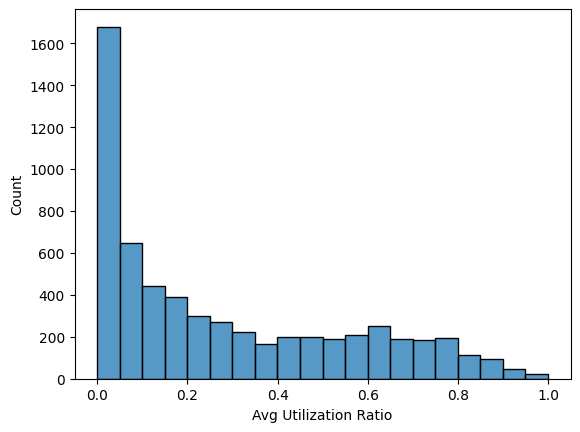

In [29]:
#histogram to understand the distribution
for i in df.select_dtypes(include = "number").columns:
  sns.histplot(data = df, x = i)
  plt.show()

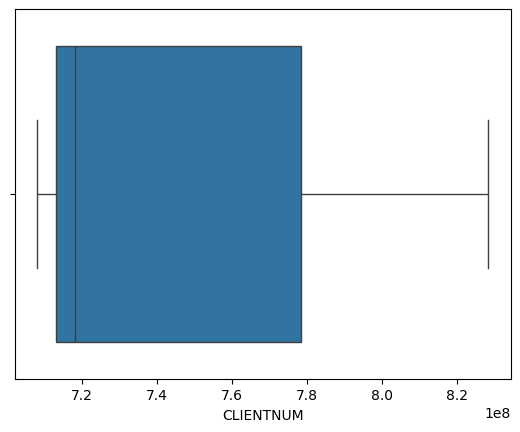

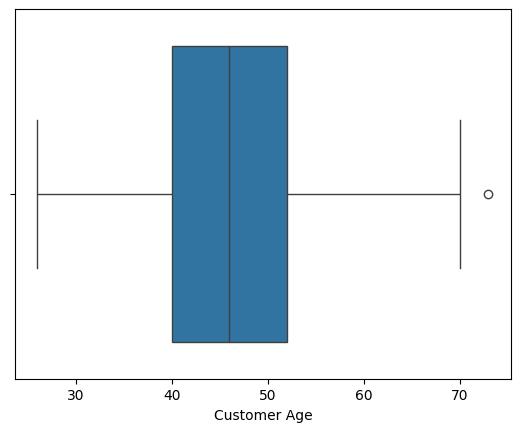

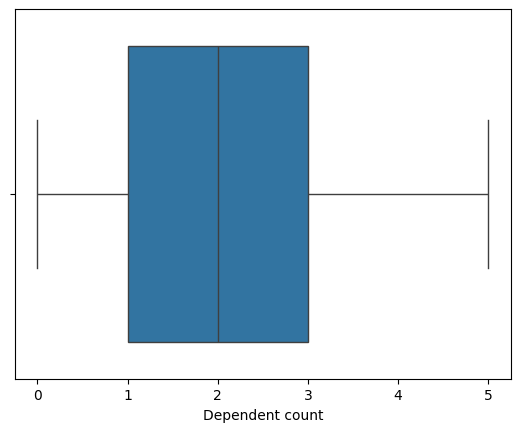

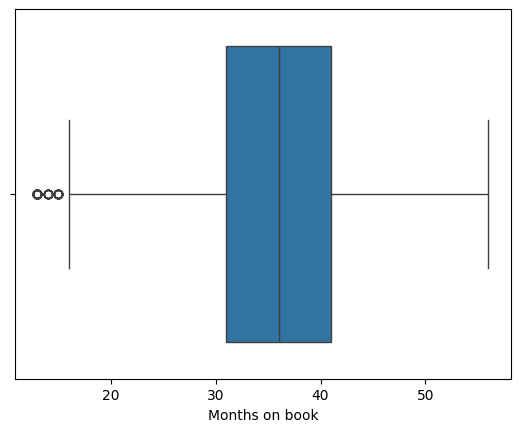

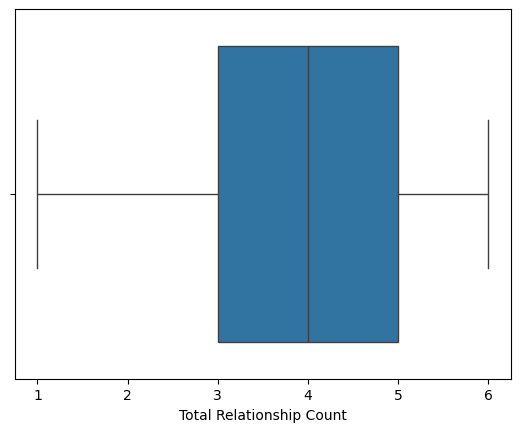

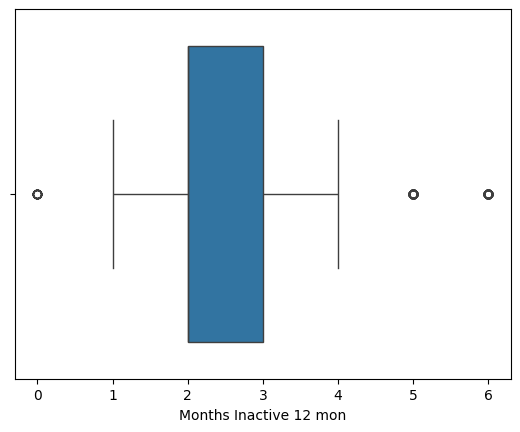

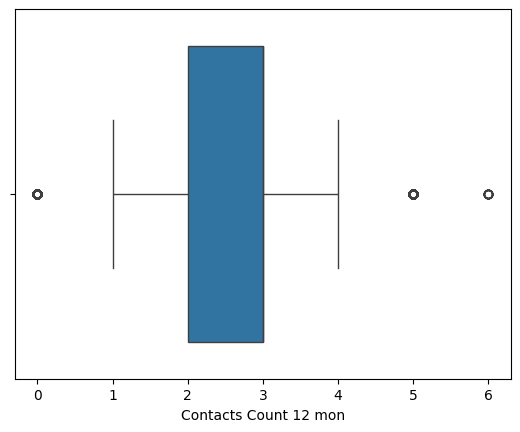

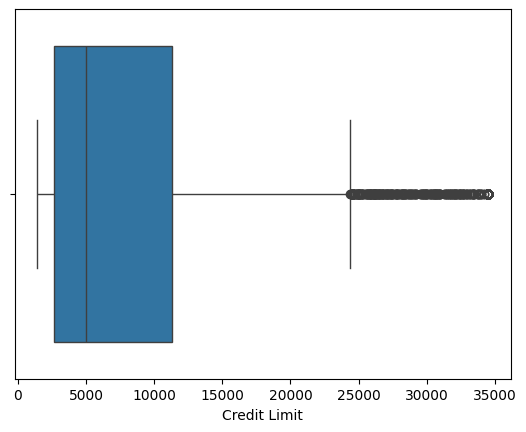

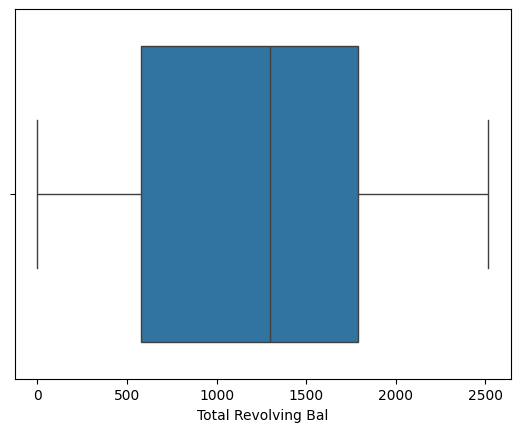

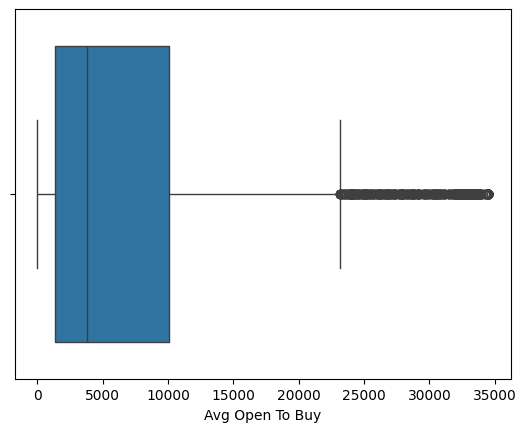

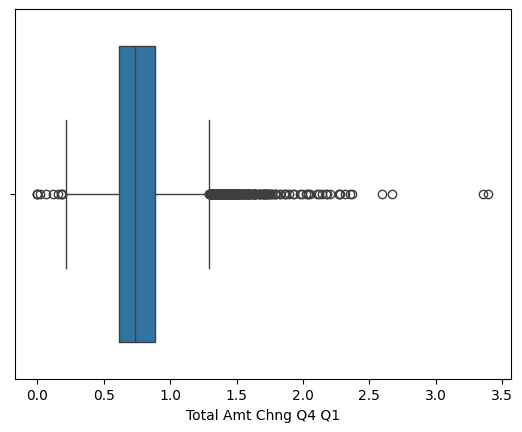

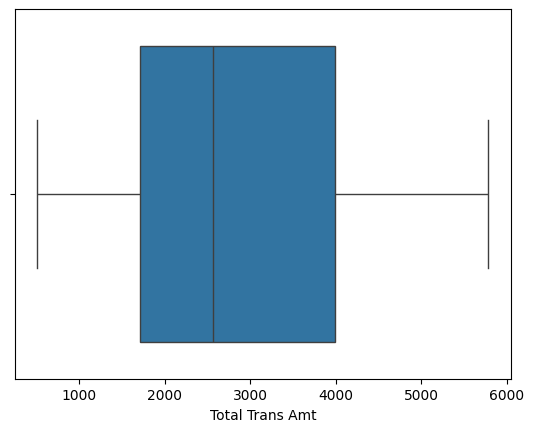

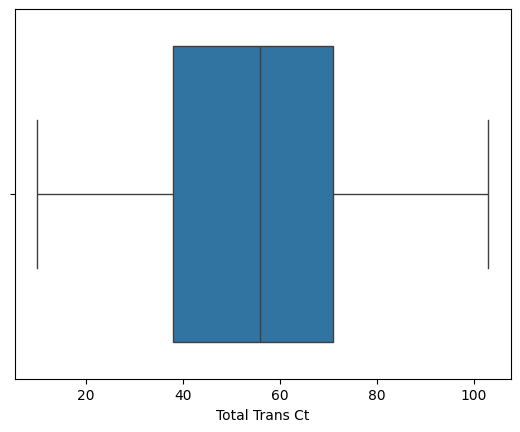

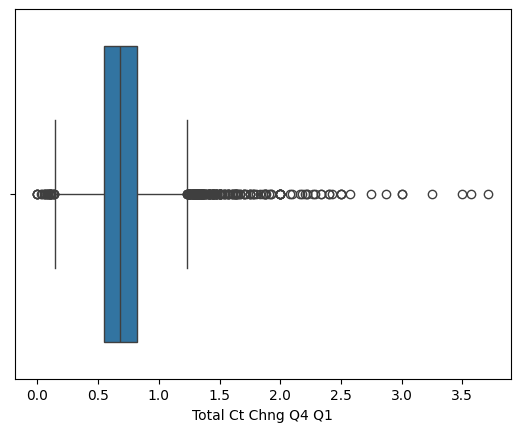

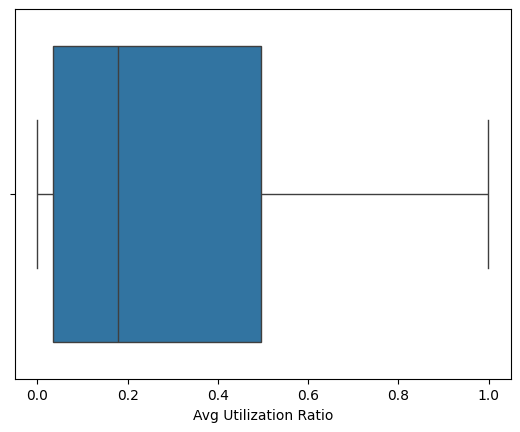

In [30]:
#Boxplot to identify outliers
for i in df.select_dtypes(include = "number").columns:
  sns.boxplot(data = df, x = i)
  plt.show()

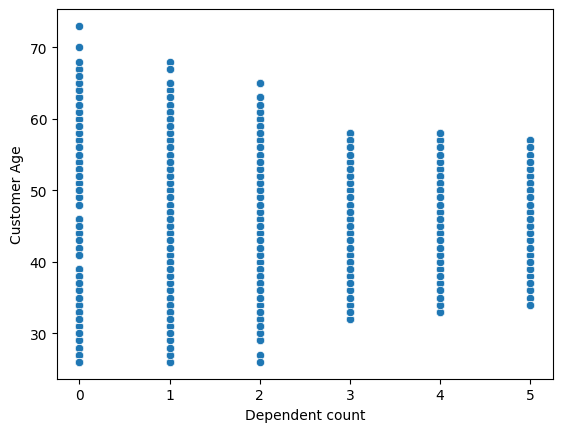

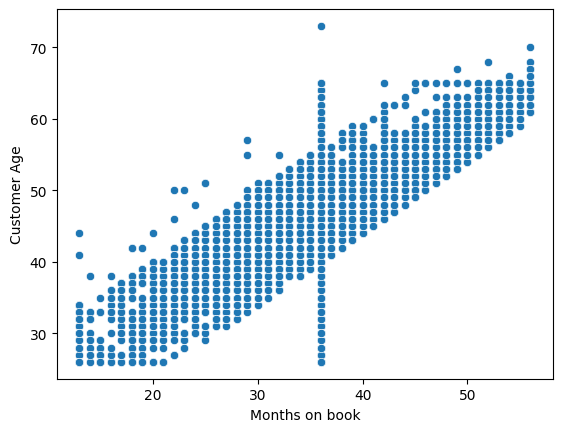

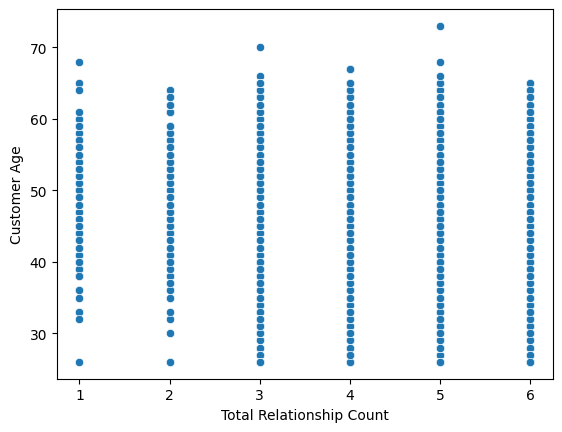

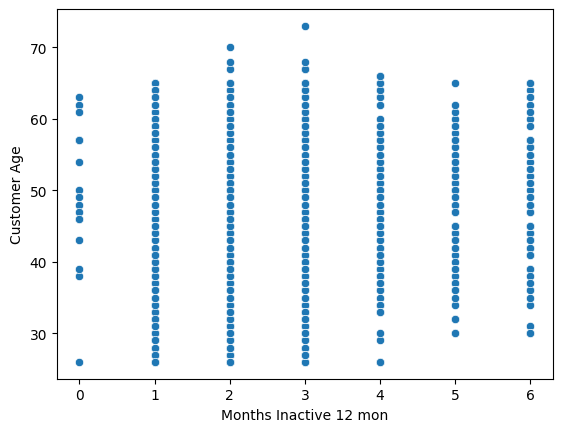

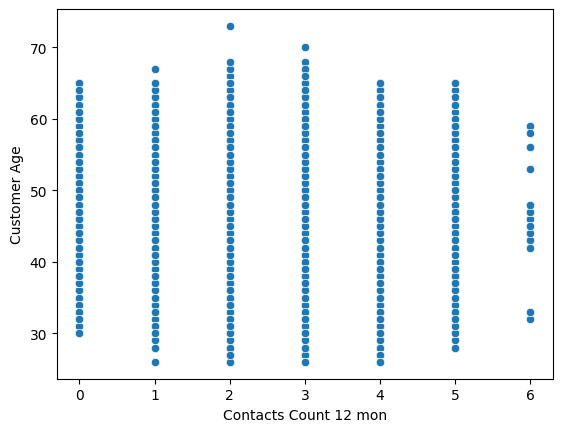

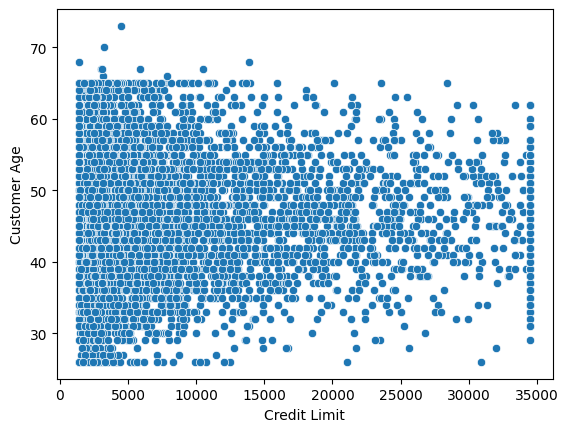

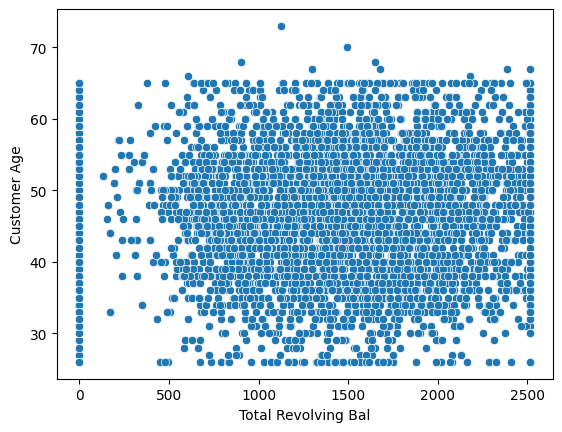

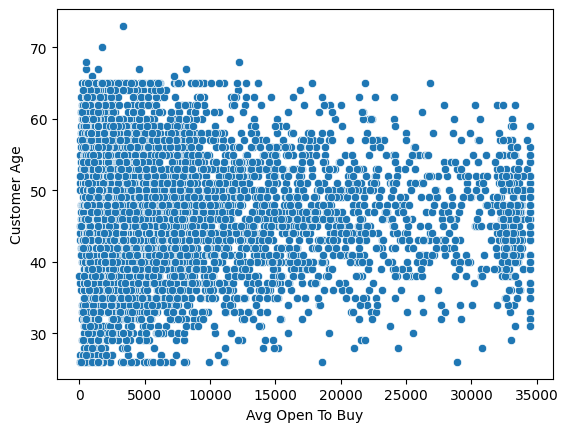

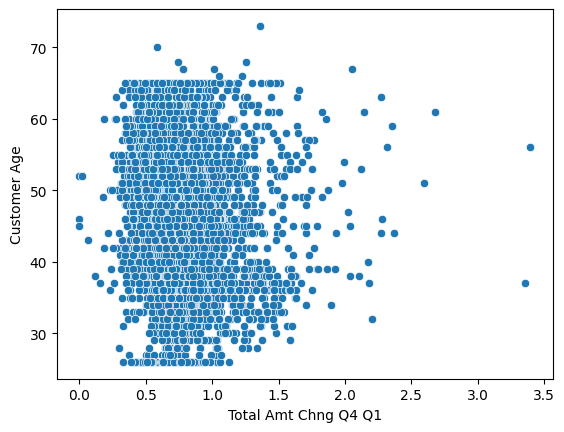

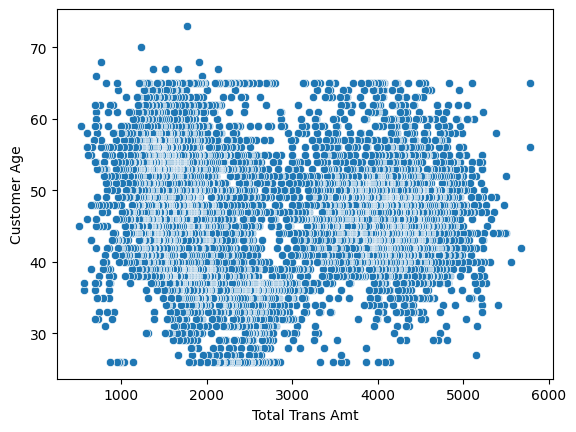

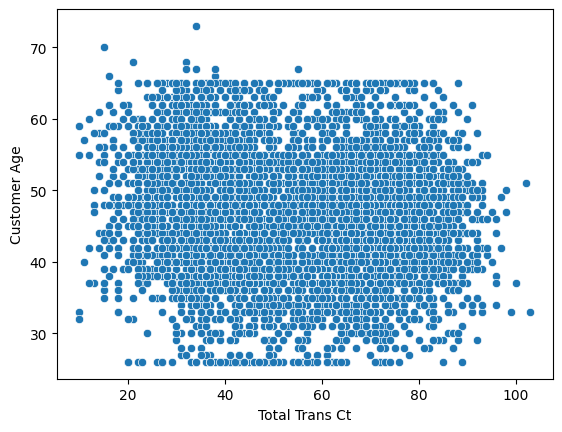

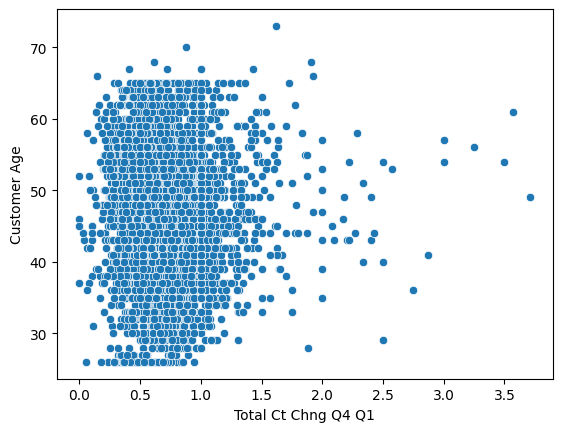

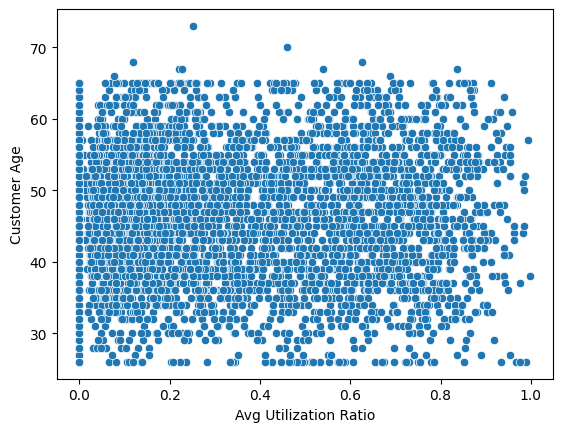

In [31]:

#scatter plot to undersatnd the relationship
df.select_dtypes(include = "number").columns
for i in [ 'Dependent count', 'Months on book',
       'Total Relationship Count', 'Months Inactive 12 mon',
       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Total Trans Amt',
       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio']:
    sns.scatterplot(data = df, x = i,y =  'Customer Age')
    plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Encoding 'Attrition Flag'
df['Attrition Flag'] = label_encoder.fit_transform(df['Attrition Flag'])

# Encoding 'Gender'
df['Gender'] = label_encoder.fit_transform(df['Gender'])

# Display the first few rows to verify the changes
print(df.head())


   CLIENTNUM  Attrition Flag  Customer Age  Gender  Dependent count  \
0  717965808               1            65       1                0   
1  716298633               1            56       0                1   
2  782548758               1            42       0                5   
3  826410708               1            40       1                4   
4  715276683               1            52       1                2   

  Education Level Marital Status Income Category Card Category  \
0         Unknown         Single     $40K - $60K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2     High School       Divorced  Less than $40K          Blue   
3         Unknown        Married     $60K - $80K          Blue   
4     High School        Married     $60K - $80K          Blue   

   Months on book  ...  Months Inactive 12 mon  Contacts Count 12 mon  \
0              54  ...                       1                      4   
1              47  ...        

                          CLIENTNUM  Attrition Flag  Customer Age    Gender  \
CLIENTNUM                  1.000000        0.015614     -0.002211  0.030797   
Attrition Flag             0.015614        1.000000     -0.050511  0.059531   
Customer Age              -0.002211       -0.050511      1.000000 -0.023337   
Gender                     0.030797        0.059531     -0.023337  1.000000   
Dependent count           -0.000120       -0.019975     -0.136640  0.013615   
Months on book             0.123873       -0.038037      0.805226 -0.014342   
Total Relationship Count   0.009594        0.334747     -0.028928  0.002120   
Months Inactive 12 mon     0.013776       -0.135005      0.028001  0.007673   
Contacts Count 12 mon      0.014823       -0.155284     -0.022764  0.015922   
Credit Limit               0.005862        0.037117     -0.003470  0.388751   
Total Revolving Bal       -0.008387        0.246843      0.009730  0.032800   
Avg Open To Buy            0.006602        0.014560 

<Axes: >

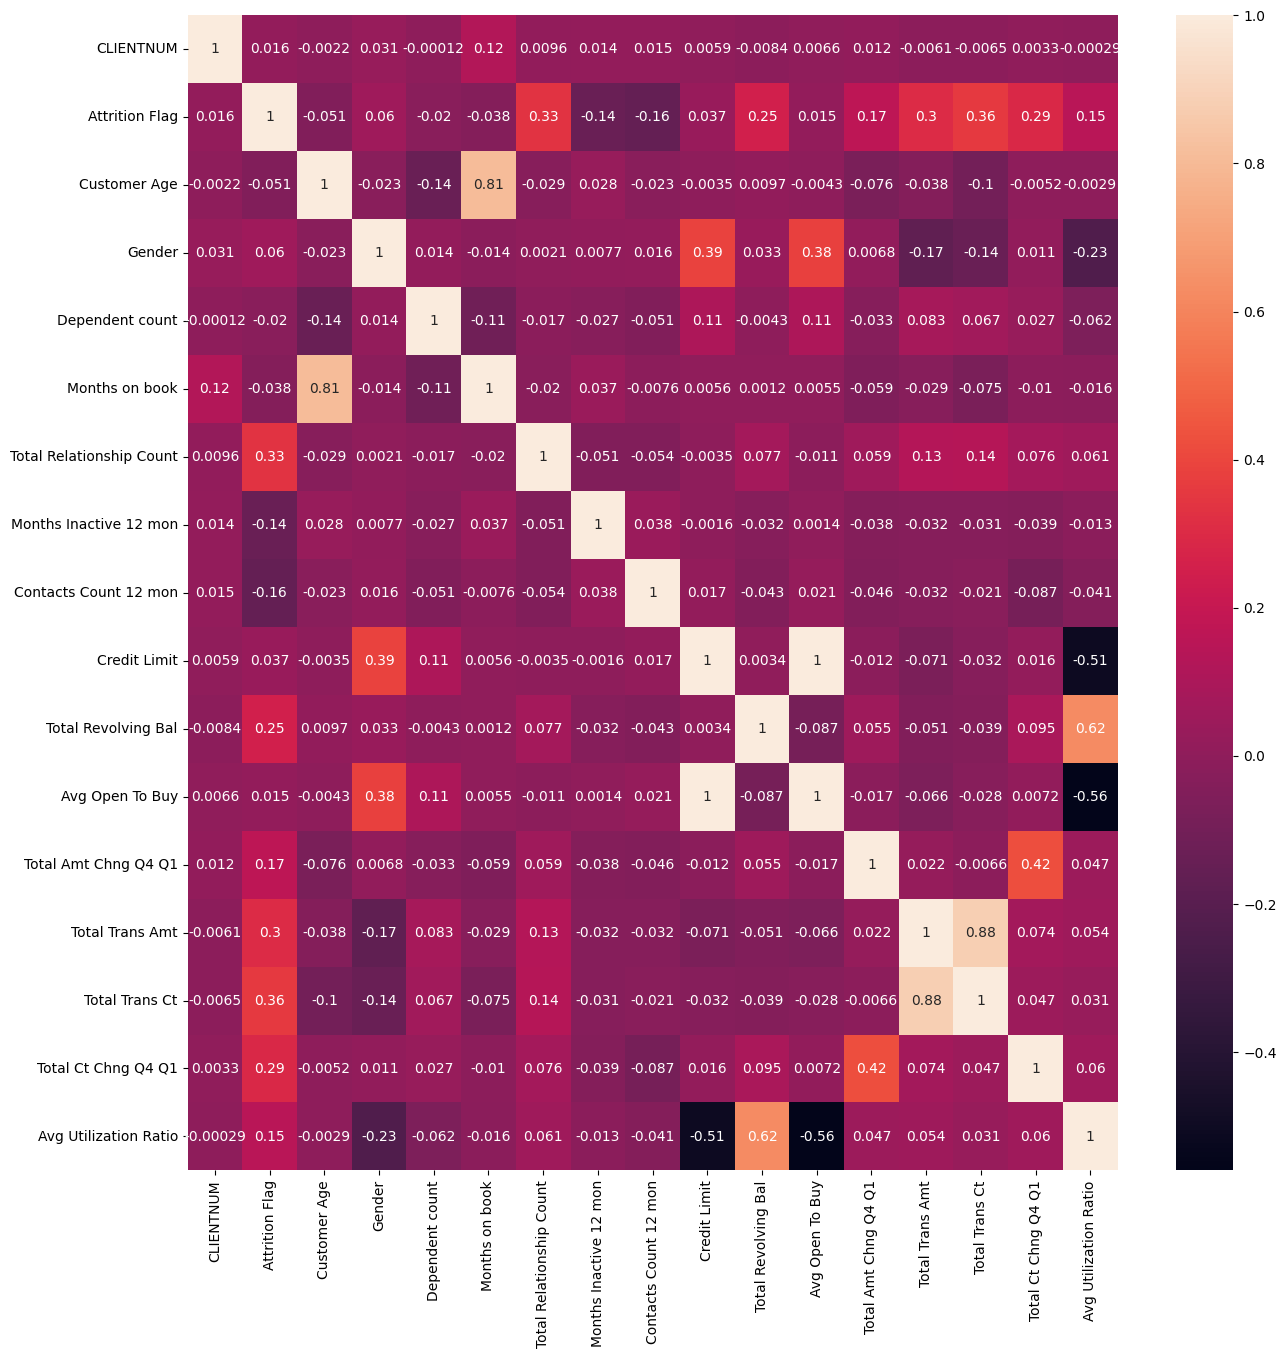

In [33]:
#corelation with heatmap to interpret the relation and multicolinearity
s = df.select_dtypes(include = "number").corr()
print(s)
plt.figure(figsize = (15,15))
sns.heatmap(s,annot = True)

In [34]:
#Missing Value Treatment
df.isnull().sum()

CLIENTNUM                   0
Attrition Flag              0
Customer Age                0
Gender                      0
Dependent count             0
Education Level             0
Marital Status              0
Income Category             0
Card Category               0
Months on book              0
Total Relationship Count    0
Months Inactive 12 mon      0
Contacts Count 12 mon       0
Credit Limit                0
Total Revolving Bal         0
Avg Open To Buy             0
Total Amt Chng Q4 Q1        0
Total Trans Amt             0
Total Trans Ct              0
Total Ct Chng Q4 Q1         0
Avg Utilization Ratio       0
dtype: int64

In [35]:
#Outlier treatment
def wisker(col):
  q1,q3 = np.percentile(col,[25,75])
  iqr = q3 - q1
  lw = q1 - 1.5*iqr
  uw = q3 + 1.5 * iqr
  return lw,uw

In [36]:
for i in [ 'Customer Age',
       'Dependent count', 'Months on book',
       'Total Relationship Count', 'Months Inactive 12 mon',
       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Total Trans Amt',
       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio']:
  lw,uw = wisker(df[i])
  df[i]= np.where(df[i]<lw,lw,df[i])
  df[i]= np.where(df[i]>uw,uw,df[i])

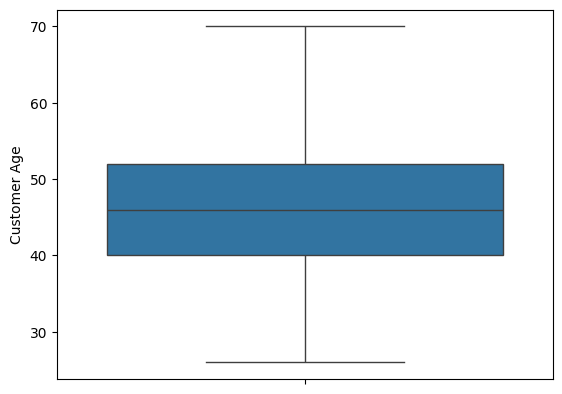

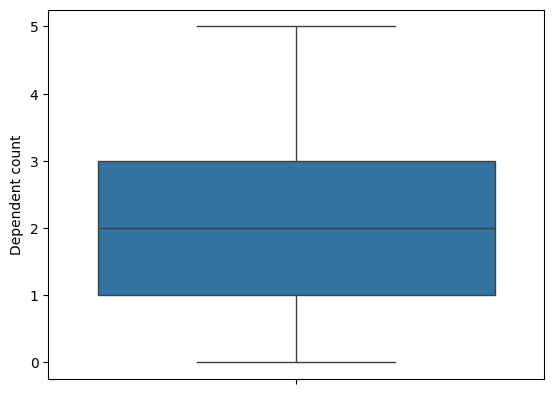

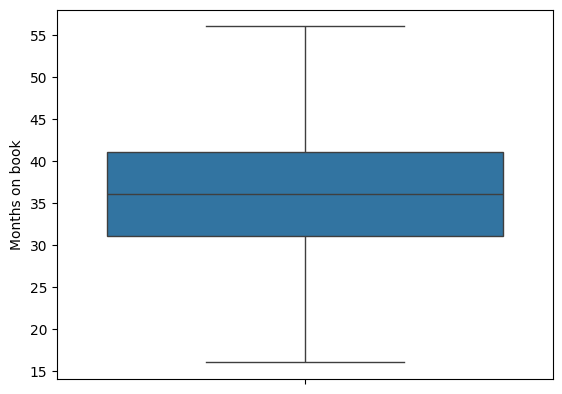

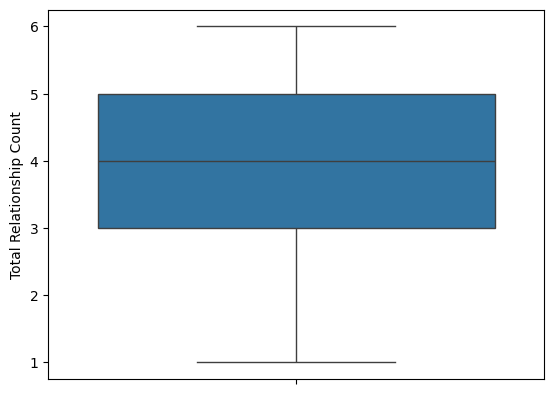

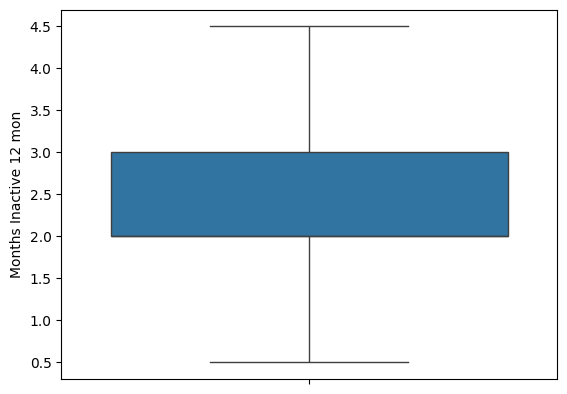

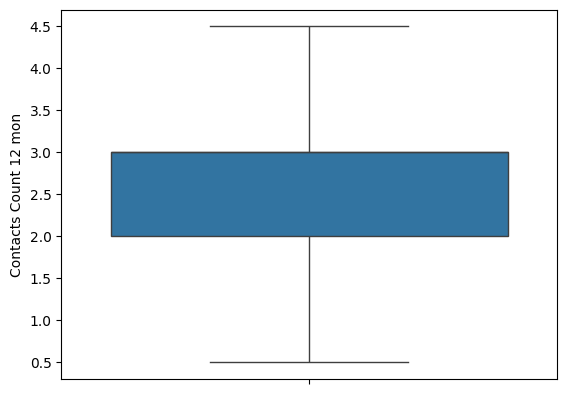

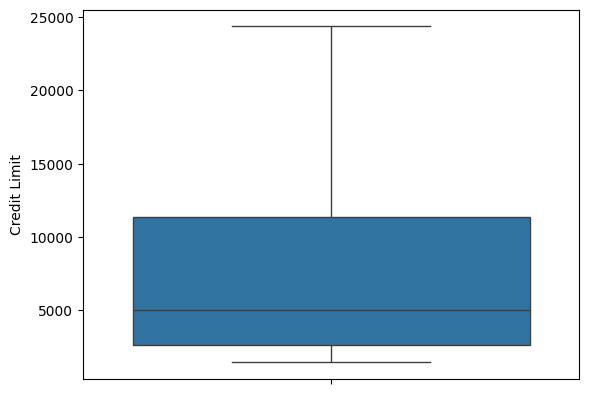

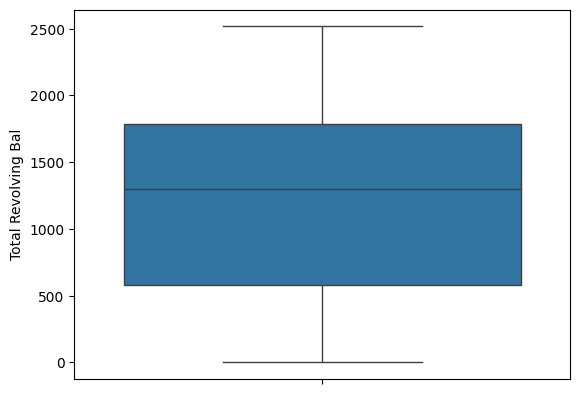

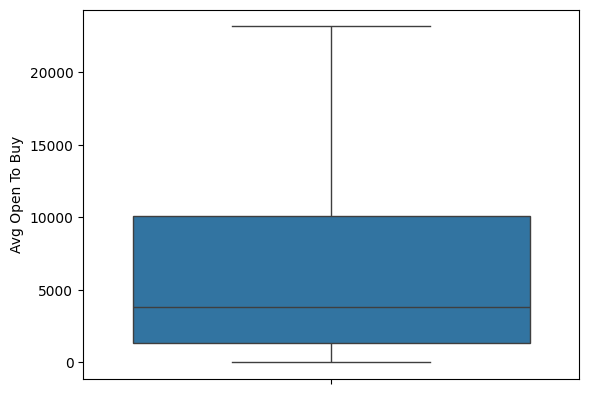

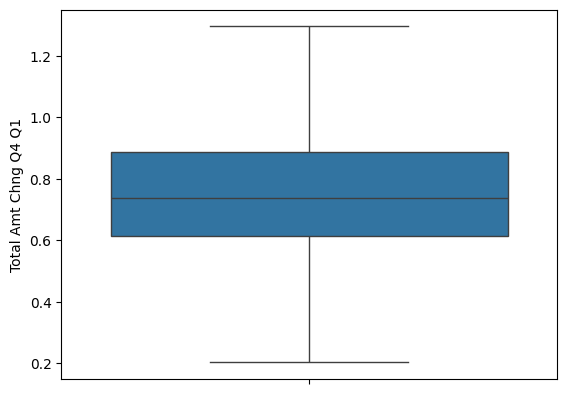

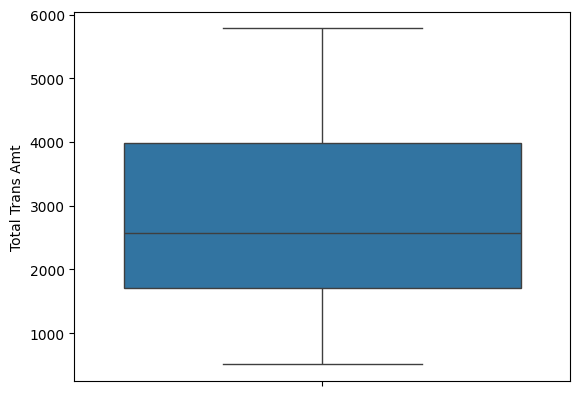

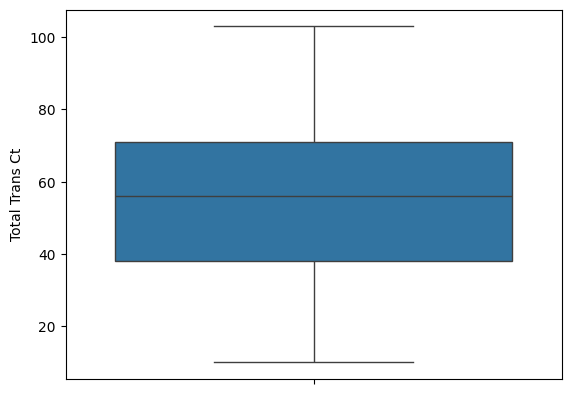

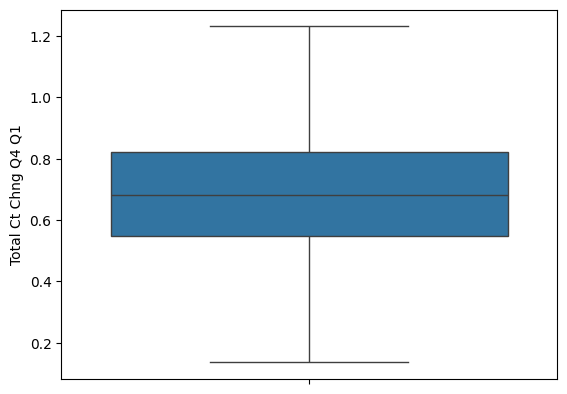

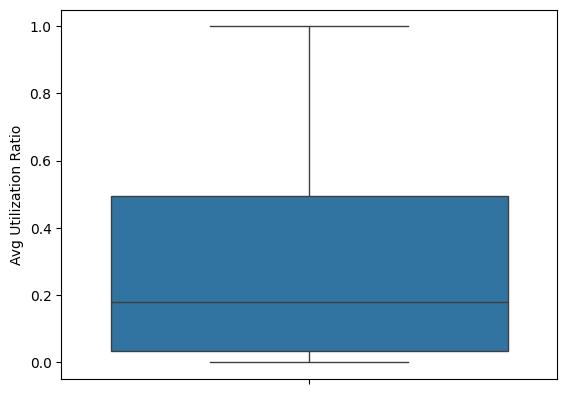

In [37]:
for i in [ 'Customer Age',
       'Dependent count', 'Months on book',
       'Total Relationship Count', 'Months Inactive 12 mon',
       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Total Trans Amt',
       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio']:
    sns.boxplot(df[i])
    plt.show()

In [38]:
# clean garbage values
df.drop_duplicates()

,CLIENTNUM,Attrition Flag,Customer Age,Gender,Dependent count,Education Level,Marital Status,Income Category,Card Category,Months on book,...,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
0,717965808,1,65.0,1,0.0,Unknown,Single,$40K - $60K,Blue,54.0,...,1.0,4.0,9383.0,829.0,8554.0,0.515,5783.0,73.0,0.622,0.088
1,716298633,1,56.0,0,1.0,Graduate,Single,Less than $40K,Blue,47.0,...,2.0,3.0,2086.0,1792.0,294.0,0.859,5774.0,84.0,0.909,0.859
2,782548758,1,42.0,0,5.0,High School,Divorced,Less than $40K,Blue,36.0,...,2.0,3.0,2069.0,1288.0,781.0,0.810,5668.0,82.0,0.640,0.623
3,826410708,1,40.0,1,4.0,Unknown,Married,$60K - $80K,Blue,36.0,...,2.0,3.0,22956.0,1407.0,21549.0,0.709,5554.0,64.0,0.600,0.061
4,715276683,1,52.0,1,2.0,High School,Married,$60K - $80K,Blue,45.0,...,1.0,4.0,24287.0,1676.0,22611.0,0.506,5495.0,69.0,0.816,0.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,803595858,0,56.0,0,3.0,High School,Married,$40K - $60K,Blue,51.0,...,2.0,1.0,1438.3,0.0,1438.3,0.597,594.0,14.0,0.556,0.000
5994,710899833,0,36.0,1,2.0,Graduate,Married,$40K - $60K,Blue,18.0,...,1.0,3.0,7758.0,1408.0,6350.0,0.365,569.0,23.0,0.643,0.181
5995,709537683,0,37.0,1,3.0,College,Married,$80K - $120K,Blue,30.0,...,4.0,3.0,11638.0,926.0,10712.0,0.262,563.0,15.0,0.364,0.080
5996,767712558,0,59.0,1,1.0,College,Single,$60K - $80K,Blue,53.0,...,3.0,3.0,14979.0,0.0,14979.0,0.710,530.0,10.0,1.000,0.000


In [39]:
# Perform one-hot encoding on the specified categorical variables
df = pd.get_dummies(df, columns=['Education Level', 'Marital Status', 'Income Category', 'Card Category'], dtype = int)

# Print the first few rows to check the new DataFrame structure
print(df.head())

# Optionally, you can also check the new columns to verify all expected dummy variables are present
print(df.columns)

   CLIENTNUM  Attrition Flag  Customer Age  Gender  Dependent count  \
0  717965808               1          65.0       1              0.0   
1  716298633               1          56.0       0              1.0   
2  782548758               1          42.0       0              5.0   
3  826410708               1          40.0       1              4.0   
4  715276683               1          52.0       1              2.0   

   Months on book  Total Relationship Count  Months Inactive 12 mon  \
0            54.0                       5.0                     1.0   
1            47.0                       5.0                     2.0   
2            36.0                       5.0                     2.0   
3            36.0                       3.0                     2.0   
4            45.0                       5.0                     1.0   

   Contacts Count 12 mon  Credit Limit  ...  Income Category_$120K +  \
0                    4.0        9383.0  ...                        0   
1 

In [40]:
df.head()

,CLIENTNUM,Attrition Flag,Customer Age,Gender,Dependent count,Months on book,Total Relationship Count,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,...,Income Category_$120K +,Income Category_$40K - $60K,Income Category_$60K - $80K,Income Category_$80K - $120K,Income Category_Less than $40K,Income Category_Unknown,Card Category_Blue,Card Category_Gold,Card Category_Platinum,Card Category_Silver
0,717965808,1,65.0,1,0.0,54.0,5.0,1.0,4.0,9383.0,...,0,1,0,0,0,0,1,0,0,0
1,716298633,1,56.0,0,1.0,47.0,5.0,2.0,3.0,2086.0,...,0,0,0,0,1,0,1,0,0,0
2,782548758,1,42.0,0,5.0,36.0,5.0,2.0,3.0,2069.0,...,0,0,0,0,1,0,1,0,0,0
3,826410708,1,40.0,1,4.0,36.0,3.0,2.0,3.0,22956.0,...,0,0,1,0,0,0,1,0,0,0
4,715276683,1,52.0,1,2.0,45.0,5.0,1.0,4.0,24287.0,...,0,0,1,0,0,0,1,0,0,0


In [41]:
#correlation of target variable with others

# Correlation with target variable
correlation = df.corr(method='spearman')['Attrition Flag']

# Print correlation (Series object)
print(correlation)

CLIENTNUM                         0.029246
Attrition Flag                    1.000000
Customer Age                     -0.050868
Gender                            0.059531
Dependent count                  -0.021320
Months on book                   -0.038768
Total Relationship Count          0.291037
Months Inactive 12 mon           -0.145440
Contacts Count 12 mon            -0.146145
Credit Limit                      0.066896
Total Revolving Bal               0.222639
Avg Open To Buy                  -0.004197
Total Amt Chng Q4 Q1              0.161464
Total Trans Amt                   0.273107
Total Trans Ct                    0.343846
Total Ct Chng Q4 Q1               0.342561
Avg Utilization Ratio             0.211294
Education Level_College           0.006309
Education Level_Doctorate        -0.040912
Education Level_Graduate         -0.005899
Education Level_High School       0.022851
Education Level_Post-Graduate    -0.003371
Education Level_Uneducated        0.002987
Education L

In [42]:
#removing column client number because it has no relation to predicting customer churn
del df['CLIENTNUM']
df

,Attrition Flag,Customer Age,Gender,Dependent count,Months on book,Total Relationship Count,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,...,Income Category_$120K +,Income Category_$40K - $60K,Income Category_$60K - $80K,Income Category_$80K - $120K,Income Category_Less than $40K,Income Category_Unknown,Card Category_Blue,Card Category_Gold,Card Category_Platinum,Card Category_Silver
0,1,65.0,1,0.0,54.0,5.0,1.0,4.0,9383.0,829.0,...,0,1,0,0,0,0,1,0,0,0
1,1,56.0,0,1.0,47.0,5.0,2.0,3.0,2086.0,1792.0,...,0,0,0,0,1,0,1,0,0,0
2,1,42.0,0,5.0,36.0,5.0,2.0,3.0,2069.0,1288.0,...,0,0,0,0,1,0,1,0,0,0
3,1,40.0,1,4.0,36.0,3.0,2.0,3.0,22956.0,1407.0,...,0,0,1,0,0,0,1,0,0,0
4,1,52.0,1,2.0,45.0,5.0,1.0,4.0,24287.0,1676.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,0,56.0,0,3.0,51.0,5.0,2.0,1.0,1438.3,0.0,...,0,1,0,0,0,0,1,0,0,0
5994,0,36.0,1,2.0,18.0,3.0,1.0,3.0,7758.0,1408.0,...,0,1,0,0,0,0,1,0,0,0
5995,0,37.0,1,3.0,30.0,3.0,4.0,3.0,11638.0,926.0,...,0,0,0,1,0,0,1,0,0,0
5996,0,59.0,1,1.0,53.0,2.0,3.0,3.0,14979.0,0.0,...,0,0,1,0,0,0,1,0,0,0


In [43]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [44]:
#selected_columns = ['Attrition Flag', 'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Total Trans Amt','Total Relationship Count','Months Inactive 12 mon','Contacts Count 12 mon']
selected_columns = ['Attrition Flag','Total Relationship Count', 'Total Trans Ct', 'Total Trans Amt', 'Total Ct Chng Q4 Q1','Avg Utilization Ratio','Months on book']

# Select only the specified columns from the DataFrame
df = df[selected_columns]


In [45]:
# Separating features and target variable
X = df.drop('Attrition Flag', axis=1)
y = df['Attrition Flag']

In [46]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Optionally split the training data into training and validation sets
#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [47]:
# Instantiate a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [48]:
# Fitting the Random Forest Classifier to the training data
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Predicting on the testing data
y_pred = rf_classifier.predict(X_test)

In [50]:
# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100

In [60]:
# Printing evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 95.33333333333334
Precision: 96.85393258426967
Recall: 97.88039364118092


In [95]:
# Performing grid search to find the best parameters for the Random Forest Classifier
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [38]:
# Instantiate a Random Forest Classifier with the best parameters
best_rf_classifier = RandomForestClassifier(**best_params, random_state=42)

# Fit the model with the best parameters to the training data
best_rf_classifier.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_best = best_rf_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy_best = accuracy_score(y_test, y_pred_best) * 100
precision_best = precision_score(y_test, y_pred_best) * 100
recall_best = recall_score(y_test, y_pred_best) * 100

NameError: name 'RandomForestClassifier' is not defined

In [92]:
# Printing evaluation metrics for the best model
print("model evaluation metrics:")
print("Accuracy:", accuracy_best)
print("Precision:", precision_best)
print("Recall:", recall_best)

model evaluation metrics:
Accuracy: 95.33333333333334
Precision: 96.85393258426967
Recall: 97.88039364118092


In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
from joblib import dump

# Define the path in your Google Drive where you want to save the model
model_path = '/content/drive/My Drive/best_rf_classifier.joblib'

# Save the model to the file
dump(best_rf_classifier, model_path)

print("Model saved to Google Drive using joblib.")

NameError: name 'best_rf_classifier' is not defined

In [68]:
import pandas as pd
import pickle

# Load the unclassified data
unclassified_data = pd.read_excel('/content/drive/MyDrive/BankChurner/Phase_3_Records.xlsx')

# Preprocessing (if necessary)
# Drop irrelevant columns (if any)
# unclassified_data = unclassified_data.drop(columns=['Irrelevant_Column1', 'Irrelevant_Column2'])
# One-hot encode categorical variables (if any)
# unclassified_data = pd.get_dummies(unclassified_data)

# Apply the trained model to classify the unclassified records
with open('RandomForestModel_updated.pkl', 'rb') as file:
    trained_model = pickle.load(file)

# Generate predictions
predictions = trained_model.predict(unclassified_data)

# Generate confidence scores for each prediction (optional)
confidence_scores = trained_model.predict_proba(unclassified_data)

# Create a DataFrame to store predictions and confidence scores
results_df = pd.DataFrame({
    'CLIENTNUM': unclassified_data['CLIENTNUM'],
    'Attrition Flag Score': predictions,
    'Confidence Proportion': [max(conf_scores) for conf_scores in confidence_scores]
})

# Save the results to an Excel file
results_df.to_excel('Phase_3_Classified_Records.xlsx', index=False)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BankChurner/Phase_3_Records.xlsx'

In [69]:
import pandas as pd

# Load the classified records file
classified_records = pd.read_excel('/content/drive/MyDrive/BankChurner/Phaase 3 records to be classified.xlsx')

# Count the number of attrited records
num_attrited_records = classified_records[classified_records['Attrition Flag'] == 'Attrited Customer'].shape[0]

# Calculate the ratio of attrited records
total_records = classified_records.shape[0]
attrition_ratio = num_attrited_records / total_records

print("Percentage of attrited records: {:.2f}%".format(attrition_ratio*100))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BankChurner/Phaase 3 records to be classified.xlsx'

In [70]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Load the Phase 3 records to be classified
phase3_records = pd.read_csv('/content/drive/MyDrive/BankChurner/Phase_3_Records.csv')

# Select categorical features for one-hot encoding
categorical_features = ['Gender', 'Education Level', 'Marital Status', 'Income Category', 'Card Category']

# Extract categorical features from Phase 3 data
X_phase3_categorical = phase3_records[categorical_features]

# Initialize OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Fit and transform the categorical features
X_phase3_encoded = one_hot_encoder.fit_transform(X_phase3_categorical)

# Create DataFrame with one-hot encoded features
X_phase3_encoded_df = pd.DataFrame(X_phase3_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_features))

# Concatenate one-hot encoded features with remaining Phase 3 data
X_phase3_processed = pd.concat([phase3_records.drop(columns=categorical_features), X_phase3_encoded_df], axis=1)

# Now X_phase3_processed contains the Phase 3 data with one-hot encoded categorical variables


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BankChurner/Phase_3_Records.csv'

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
import pandas as pd

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/BankChurner/BankChurners for EDA 2024.csv')

# Now you can proceed with your analysis

In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/BankChurner/BankChurners for EDA 2024.csv')  # Replace '/path/to/your/dataset.csv' with the path to your dataset

# Create contingency tables (cross-tabulations) for each pair of variables
contingency_tables = {}
categorical_variables = ['Card Category', 'Marital Status']  # Update with your categorical variables of interest

for var1 in categorical_variables:
    for var2 in data.columns:
        if var2 not in categorical_variables:  # Exclude the same variable and non-categorical variables
            contingency_table = pd.crosstab(data[var1], data[var2])
            contingency_tables[(var1, var2)] = contingency_table

# Perform chi-square test of independence for each contingency table
results = {}
for (var1, var2), contingency_table in contingency_tables.items():
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results[(var1, var2)] = {'chi2': chi2, 'p-value': p}

# Check the results
for (var1, var2), result in results.items():
    print(f"Chi-square test of independence between '{var1}' and '{var2}':")
    print(f"   - Chi-square statistic: {result['chi2']}")
    print(f"   - p-value: {result['p-value']}")
    if result['p-value'] < 0.05:
        print("   - There is a significant association between the variables.")
    else:
        print("   - There is no significant association between the variables.")


Chi-square test of independence between 'Card Category' and 'CLIENTNUM':
   - Chi-square statistic: 17994.0
   - p-value: 0.4922893468128487
   - There is no significant association between the variables.
Chi-square test of independence between 'Card Category' and 'Attrition Flag':
   - Chi-square statistic: 3.2798619411368604
   - p-value: 0.35045533675371526
   - There is no significant association between the variables.
Chi-square test of independence between 'Card Category' and 'Customer Age':
   - Chi-square statistic: 151.2822344662788
   - p-value: 0.12019836738453084
   - There is no significant association between the variables.
Chi-square test of independence between 'Card Category' and 'Gender':
   - Chi-square statistic: 19.99131622424241
   - p-value: 0.0001704472662870363
   - There is a significant association between the variables.
Chi-square test of independence between 'Card Category' and 'Dependent count':
   - Chi-square statistic: 32.75220354286516
   - p-value: 0.

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency

# Assuming you have a DataFrame named 'data' containing 'Card Category' and 'Marital Status'
contingency_table = pd.crosstab(data['Card Category'], data['Marital Status'])

# Perform chi-square test of independence
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("P-value:", p_val)
print("Degrees of freedom:", dof)
print("Expected frequencies table:")
print(expected)


Chi-square statistic: 33.858031488683984
P-value: 9.458695563301454e-05
Degrees of freedom: 9
Expected frequencies table:
[[4.18942648e+02 2.74165188e+03 2.16026209e+03 3.77143381e+02]
 [2.42630877e+00 1.58782928e+01 1.25111704e+01 2.18422808e+00]
 [2.20573525e-01 1.44348116e+00 1.13737913e+00 1.98566189e-01]
 [1.94104702e+01 1.27026342e+02 1.00089363e+02 1.74738246e+01]]


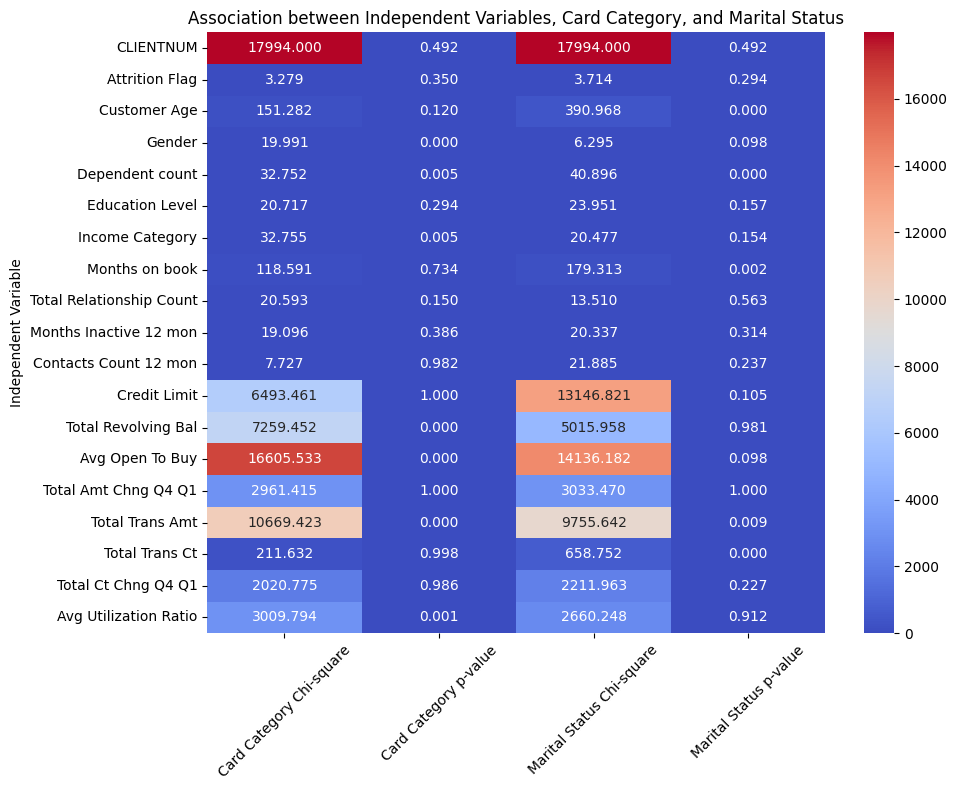

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dataframe with Chi-square statistics and p-values
data = {
    'Independent Variable': ['CLIENTNUM', 'Attrition Flag', 'Customer Age', 'Gender', 'Dependent count',
                             'Education Level', 'Income Category', 'Months on book', 'Total Relationship Count',
                             'Months Inactive 12 mon', 'Contacts Count 12 mon', 'Credit Limit',
                             'Total Revolving Bal', 'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Total Trans Amt',
                             'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio'],
    'Card Category Chi-square': [17994.0, 3.279, 151.282, 19.991, 32.752, 20.717, 32.755, 118.591, 20.593,
                                  19.096, 7.727, 6493.461, 7259.452, 16605.533, 2961.415, 10669.423,
                                  211.632, 2020.775, 3009.794],
    'Card Category p-value': [0.492, 0.350, 0.120, 0.000170, 0.005079, 0.294, 0.005074, 0.734, 0.150,
                               0.386, 0.982, 1.0, 5.097e-71, 2.929e-52, 1.0, 2.173e-18, 0.998,
                               0.986, 0.000529],
    'Marital Status Chi-square': [17994.0, 3.714, 390.968, 6.295, 40.896, 23.951, 20.477, 179.313,
                                   13.510, 20.337, 21.885, 13146.821, 5015.958, 14136.182, 3033.470,
                                   9755.642, 658.752, 2211.963, 2660.248],
    'Marital Status p-value': [0.492, 0.294, 1.915e-27, 0.098, 0.000332, 0.157, 0.154, 0.00227,
                                0.563, 0.314, 0.237, 0.105, 0.981, 0.098, 1.0, 0.00922, 2.568e-33,
                                0.227, 0.912]
}

df = pd.DataFrame(data)

# Set the index to 'Independent Variable'
df.set_index('Independent Variable', inplace=True)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Association between Independent Variables, Card Category, and Marital Status")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Compute Cramer's V
cramers_v_value = cramers_v(pd.crosstab(df['Card Category'], df['Marital Status']))

print("Cramer's V value:", cramers_v_value)

# Determine if there is a significant association between the variables based on the Cramer's V value
if cramers_v_value > 0.5:
    print("There is a strong association between 'Card Category' and 'Marital Status'.")
elif 0.1 < cramers_v_value <= 0.5:
    print("There is a moderate association between 'Card Category' and 'Marital Status'.")
else:
    print("There is a weak association between 'Card Category' and 'Marital Status'.")


Cramer's V value: 1.0000000000000002
There is a strong association between 'Card Category' and 'Marital Status'.


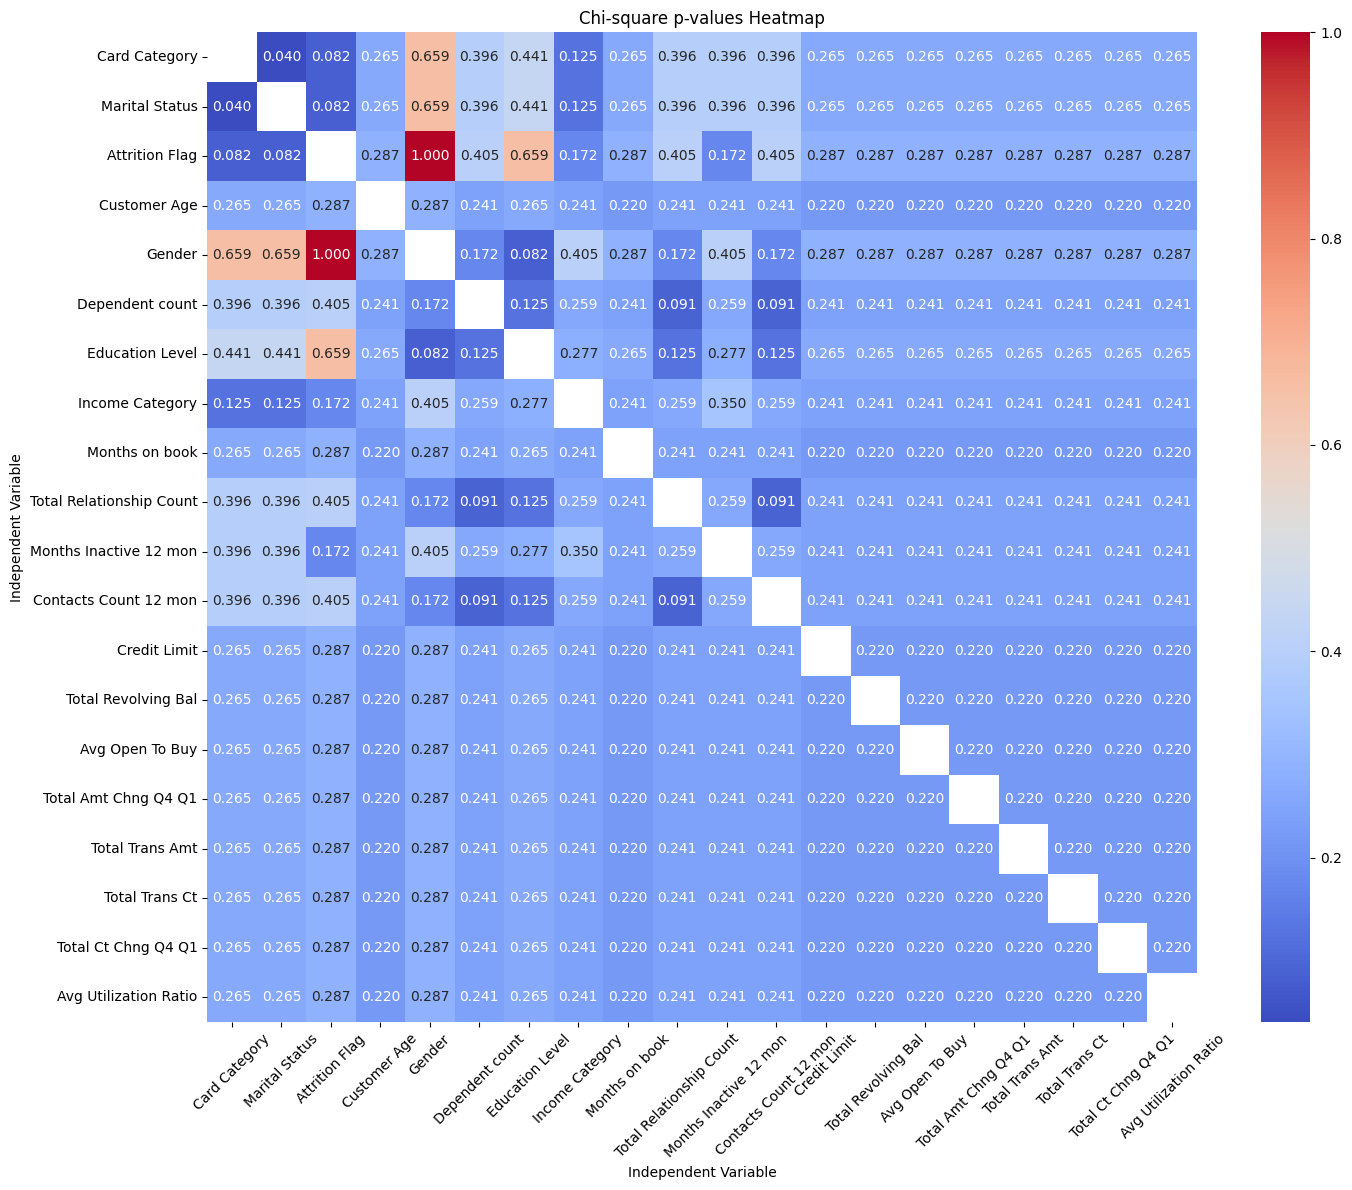

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Sample data (replace this with your actual data)
data = {
    'Card Category': ['A', 'B', 'A', 'B', 'C'],
    'Marital Status': ['Single', 'Married', 'Single', 'Married', 'Divorced'],
    'Attrition Flag': ['Yes', 'No', 'Yes', 'No', 'No'],
    'Customer Age': [35, 45, 30, 50, 40],
    'Gender': ['M', 'F', 'F', 'M', 'M'],
    'Dependent count': [1, 2, 0, 3, 1],
    'Education Level': ['High School', 'Graduate', 'Graduate', 'Post-Graduate', 'High School'],
    'Income Category': ['$50K - $100K', '$100K - $150K', '$50K - $100K', '$150K +', '$30K - $50K'],
    'Months on book': [24, 36, 12, 48, 60],
    'Total Relationship Count': [3, 4, 2, 5, 3],
    'Months Inactive 12 mon': [2, 1, 3, 0, 1],
    'Contacts Count 12 mon': [2, 3, 1, 4, 2],
    'Credit Limit': [5000, 10000, 8000, 15000, 20000],
    'Total Revolving Bal': [1000, 2000, 500, 1500, 3000],
    'Avg Open To Buy': [4000, 8000, 7500, 13500, 17000],
    'Total Amt Chng Q4 Q1': [0.2, 0.3, 0.1, 0.25, 0.15],
    'Total Trans Amt': [2000, 3000, 1500, 4000, 5000],
    'Total Trans Ct': [10, 15, 8, 20, 25],
    'Total Ct Chng Q4 Q1': [0.1, 0.2, 0.05, 0.3, 0.25],
    'Avg Utilization Ratio': [0.2, 0.25, 0.1, 0.3, 0.15]
}

# Convert data to DataFrame
df = pd.DataFrame(data)

# Define a function to compute Chi-square statistics and p-values for each pair of variables
def compute_chi2_pvalues(df):
    variables = df.columns
    p_values = pd.DataFrame(index=variables, columns=variables, dtype=np.float64)
    chi2_stats = pd.DataFrame(index=variables, columns=variables, dtype=np.float64)
    for var1 in variables:
        for var2 in variables:
            if var1 != var2:
                contingency_table = pd.crosstab(df[var1], df[var2])
                chi2, p, _, _ = chi2_contingency(contingency_table)
                p_values.loc[var1, var2] = p
                chi2_stats.loc[var1, var2] = chi2
    return chi2_stats, p_values

# Compute Chi-square statistics and p-values
chi2_stats, p_values = compute_chi2_pvalues(df)

# Create the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(p_values, annot=True, fmt=".3f", cmap="coolwarm", cbar=True, square=True)
plt.title("Chi-square p-values Heatmap")
plt.xlabel("Independent Variable")
plt.ylabel("Independent Variable")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [14]:
data = pd.read_csv('/content/drive/MyDrive/BankChurner/BankChurners for EDA 2024.csv')
data.head()

,CLIENTNUM,Attrition Flag,Customer Age,Gender,Dependent count,Education Level,Marital Status,Income Category,Card Category,Months on book,...,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
0,717965808,Existing Customer,65,M,0,Unknown,Single,$40K - $60K,Blue,54,...,1,4,9383.0,829,8554.0,0.515,5783,73,0.622,0.088
1,716298633,Existing Customer,56,F,1,Graduate,Single,Less than $40K,Blue,47,...,2,3,2086.0,1792,294.0,0.859,5774,84,0.909,0.859
2,782548758,Existing Customer,42,F,5,High School,Divorced,Less than $40K,Blue,36,...,2,3,2069.0,1288,781.0,0.810,5668,82,0.640,0.623
3,826410708,Existing Customer,40,M,4,Unknown,Married,$60K - $80K,Blue,36,...,2,3,22956.0,1407,21549.0,0.709,5554,64,0.600,0.061
4,715276683,Existing Customer,52,M,2,High School,Married,$60K - $80K,Blue,45,...,1,4,24287.0,1676,22611.0,0.506,5495,69,0.816,0.069


In [15]:
# Dropping irrelevant columns (e.g., 'CLIENTNUM')
data = data.drop(columns=['CLIENTNUM'])

data.head()

,Attrition Flag,Customer Age,Gender,Dependent count,Education Level,Marital Status,Income Category,Card Category,Months on book,Total Relationship Count,Months Inactive 12 mon,Contacts Count 12 mon,Credit Limit,Total Revolving Bal,Avg Open To Buy,Total Amt Chng Q4 Q1,Total Trans Amt,Total Trans Ct,Total Ct Chng Q4 Q1,Avg Utilization Ratio
0,Existing Customer,65,M,0,Unknown,Single,$40K - $60K,Blue,54,5,1,4,9383.0,829,8554.0,0.515,5783,73,0.622,0.088
1,Existing Customer,56,F,1,Graduate,Single,Less than $40K,Blue,47,5,2,3,2086.0,1792,294.0,0.859,5774,84,0.909,0.859
2,Existing Customer,42,F,5,High School,Divorced,Less than $40K,Blue,36,5,2,3,2069.0,1288,781.0,0.810,5668,82,0.640,0.623
3,Existing Customer,40,M,4,Unknown,Married,$60K - $80K,Blue,36,3,2,3,22956.0,1407,21549.0,0.709,5554,64,0.600,0.061
4,Existing Customer,52,M,2,High School,Married,$60K - $80K,Blue,45,5,1,4,24287.0,1676,22611.0,0.506,5495,69,0.816,0.069


In [16]:
# Split the data into features and target variable
X = data.drop(columns=['Attrition Flag'])  # Features
y = data['Attrition Flag']  # Target variable

In [17]:
# One-hot encode categorical variables

X = pd.get_dummies(X)

In [18]:
from sklearn.model_selection import train_test_split

# Now you can use train_test_split function
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [19]:
# Split the data into training, testing, and validation sets

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [20]:
from sklearn.tree import DecisionTreeClassifier

# Now you can use DecisionTreeClassifier class
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [21]:
# Initialize and train the Decision Tree model

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
# Testing the model

y_pred_test = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Now you can use accuracy_score, precision_score, and recall_score functions
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='Attrited Customer')
recall_test = recall_score(y_test, y_pred_test, pos_label='Attrited Customer')


In [24]:
# Calculate evaluation metrics for testing set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='Attrited Customer')
recall_test = recall_score(y_test, y_pred_test, pos_label='Attrited Customer')

In [25]:
print("Testing Set Metrics:")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)


Testing Set Metrics:
Accuracy: 0.9288888888888889
Precision: 0.6724137931034483
Recall: 0.75


In [26]:
y_pred_val = model.predict(X_val)

In [27]:
# Calculate evaluation metrics for validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
precision_val = precision_score(y_val, y_pred_val, pos_label='Attrited Customer')
recall_val = recall_score(y_val, y_pred_val, pos_label='Attrited Customer')

In [28]:
# Calculate evaluation metrics for validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
precision_val = precision_score(y_val, y_pred_val, pos_label='Attrited Customer')
recall_val = recall_score(y_val, y_pred_val, pos_label='Attrited Customer')

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate evaluation metrics for training set
y_pred_train = model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, pos_label='Attrited Customer')
recall_train = recall_score(y_train, y_pred_train, pos_label='Attrited Customer')

# Calculate evaluation metrics for testing set
y_pred_test = model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='Attrited Customer')
recall_test = recall_score(y_test, y_pred_test, pos_label='Attrited Customer')

# Calculate evaluation metrics for validation set
y_pred_val = model.predict(X_val)
accuracy_val = accuracy_score(y_val, y_pred_val)
precision_val = precision_score(y_val, y_pred_val, pos_label='Attrited Customer')
recall_val = recall_score(y_val, y_pred_val, pos_label='Attrited Customer')


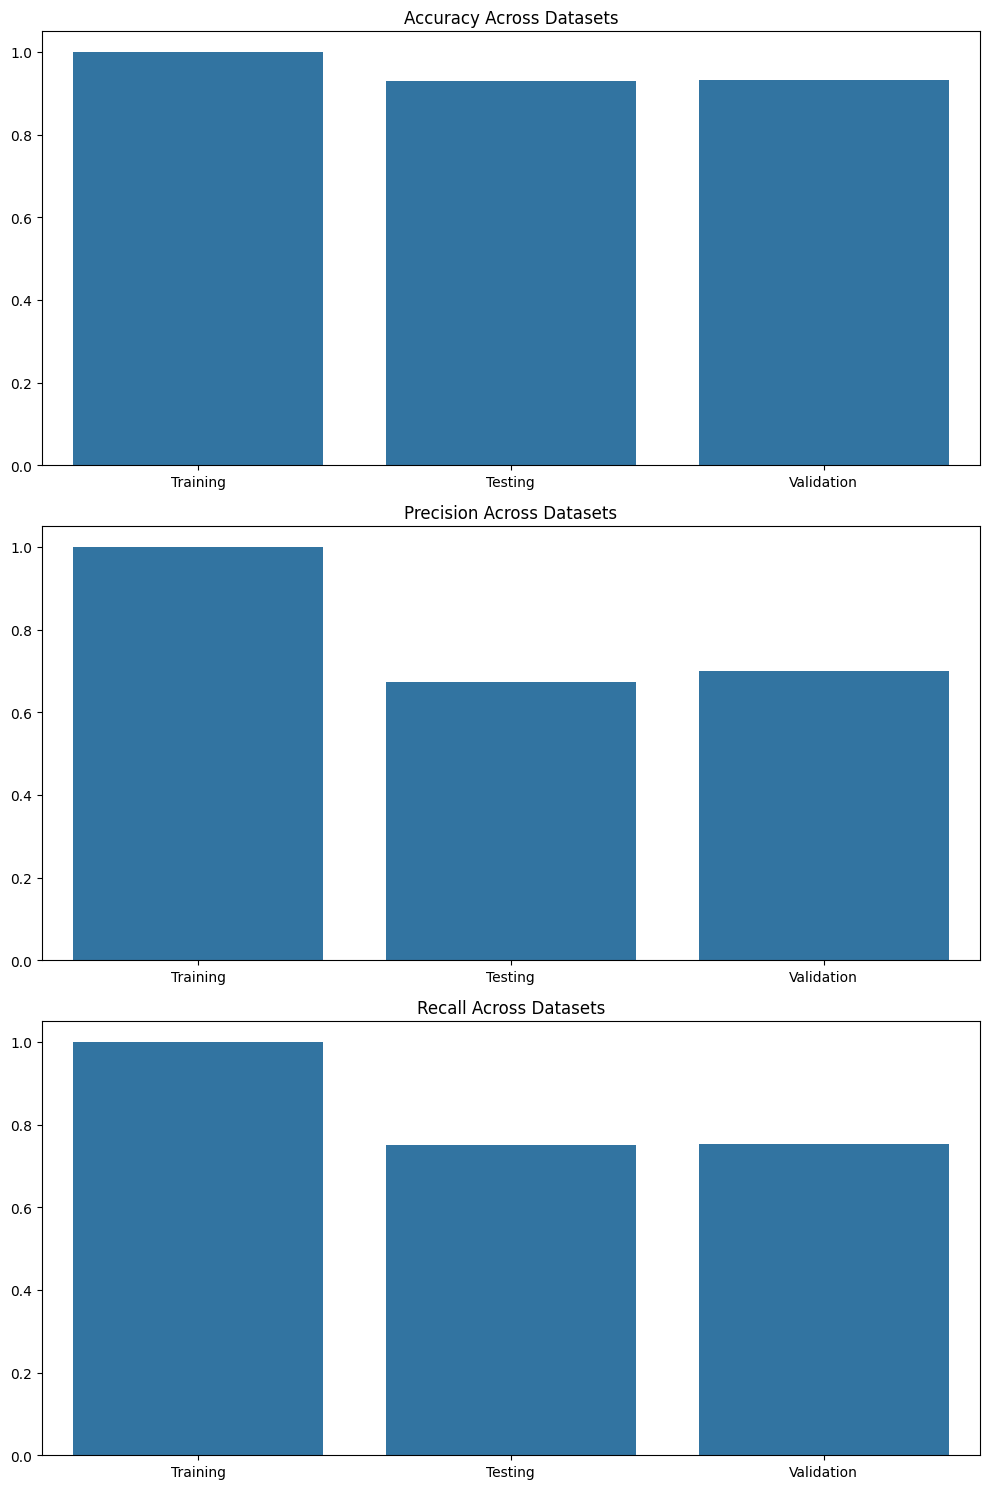

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the data for plotting
datasets = ['Training', 'Testing', 'Validation']
accuracy = [accuracy_train, accuracy_test, accuracy_val]
precision = [precision_train, precision_test, precision_val]
recall = [recall_train, recall_test, recall_val]

# Create subplots for accuracy, precision, and recall
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot accuracy
sns.barplot(x=datasets, y=accuracy, ax=axes[0])
axes[0].set_title('Accuracy Across Datasets')

# Plot precision
sns.barplot(x=datasets, y=precision, ax=axes[1])
axes[1].set_title('Precision Across Datasets')

# Plot recall
sns.barplot(x=datasets, y=recall, ax=axes[2])
axes[2].set_title('Recall Across Datasets')

# Show plots
plt.tight_layout()
plt.show()


In [31]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)

# Calculate the mean and standard deviation of the cross-validation scores
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()

print("Mean cross-validation score:", mean_cv_score)
print("Standard deviation of cross-validation scores:", std_cv_score)


Cross-validation scores: [0.91416667 0.95083333 0.56       0.21017515 0.32527106]
Mean cross-validation score: 0.5920892410341951
Standard deviation of cross-validation scores: 0.3001703614351933


In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Step 1: Make predictions
y_pred = model.predict(X_test)

# Step 2: Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 3: Verify with provided calculations
TP, FP, FN, TN = conf_matrix.ravel()
provided_values = {'TP': 5071, 'FP': 321, 'FN': 141, 'TN': 465}

# Step 4: Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Attrited Customer')
recall = recall_score(y_test, y_pred, pos_label='Attrited Customer')

# Step 5: Compare with provided metrics
provided_accuracy = (TP + TN) / (TP + TN + FP + FN)
provided_precision = TP / (TP + FP)
provided_recall = TP / (TP + FN)

print("Calculated Accuracy:", accuracy)
print("Calculated Precision:", precision)
print("Calculated Recall:", recall)
print("Provided Accuracy:", provided_accuracy)
print("Provided Precision:", provided_precision)
print("Provided Recall:", provided_recall)


Calculated Accuracy: 0.9288888888888889
Calculated Precision: 0.6724137931034483
Calculated Recall: 0.75
Provided Accuracy: 0.9288888888888889
Provided Precision: 0.75
Provided Recall: 0.6724137931034483


In [33]:
import random

# Step 1: Select 100 records randomly from the testing set
random.seed(42)  # Set seed for reproducibility
selected_indices = random.sample(range(len(X_test)), 100)
selected_X_test = X_test.iloc[selected_indices]
selected_y_test = y_test.iloc[selected_indices]

# Step 2: Use the trained model to predict 'Attrition Flag' for the selected records
predictions = model.predict(selected_X_test)

# Step 3: Compare predicted values with actual values
mismatches = sum(pred != actual for pred, actual in zip(predictions, selected_y_test))

# Step 4: Calculate percentage of correct classification
percent_correct = (1 - mismatches / 100) * 100
print("Percentage of correct classification:", percent_correct)


Percentage of correct classification: 90.0


In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/BankChurner/BankChurners for EDA 2024.csv')

# Dropping irrelevant columns (e.g., 'CLIENTNUM')
data = data.drop(columns=['CLIENTNUM'])

# Convert categorical variables into numerical format using one-hot encoding
data = pd.get_dummies(data)

# Split the data into features and target variable
X = data.drop(columns=['Attrition Flag'])  # Features
y = data['Attrition Flag']  # Target variable

# Split the data into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the testing set
y_pred_test = dt_model.predict(X_test)

# Calculate evaluation metrics for the testing set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='Attrited Customer')
recall_test = recall_score(y_test, y_pred_test, pos_label='Attrited Customer')

print("Testing Set Metrics:")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)

# Make predictions on the validation set
y_pred_val = dt_model.predict(X_val)

# Calculate evaluation metrics for the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
precision_val = precision_score(y_val, y_pred_val, pos_label='Attrited Customer')
recall_val = recall_score(y_val, y_pred_val, pos_label='Attrited Customer')

print("\nValidation Set Metrics:")
print("Accuracy:", accuracy_val)
print("Precision:", precision_val)
print("Recall:", recall_val)


KeyError: "['Attrition Flag'] not found in axis"

In [51]:
# Display column names
print(data.columns)


Index(['Customer Age', 'Dependent count', 'Months on book',
       'Total Relationship Count', 'Months Inactive 12 mon',
       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Total Trans Amt',
       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio',
       'Attrition Flag_Attrited Customer', 'Attrition Flag_Existing Customer',
       'Gender_F', 'Gender_M', 'Education Level_College',
       'Education Level_Doctorate', 'Education Level_Graduate',
       'Education Level_High School', 'Education Level_Post-Graduate',
       'Education Level_Uneducated', 'Education Level_Unknown',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'Marital Status_Unknown',
       'Income Category_$120K +', 'Income Category_$40K - $60K',
       'Income Category_$60K - $80K', 'Income Category_$80K - $120K',
       'Income Category_Less than $40K', 'Income Category_Unknown',
       'C

In [52]:
# Split the data into features and target variable
X = data.drop(columns=['Attrition Flag_Attrited Customer', 'Attrition Flag_Existing Customer'])  # Features
y = data['Attrition Flag_Attrited Customer']  # Target variable


In [54]:
# One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train)


In [74]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/BankChurner/BankChurners for EDA 2024.csv')


# Define specific attributes to include
selected_attributes = ['Gender', 'Education Level', 'Marital Status', 'Income Category', 'Card Category', 'Customer Age', 'Total Relationship Count', 'Months Inactive 12 mon',
                       'Contacts Count 12 mon', 'Credit Limit', 'Total Revolving Bal',
                       'Avg Open To Buy', 'Total Amt Chng Q4 Q1', 'Dependent count', 'Total Trans Amt',
                       'Total Trans Ct', 'Total Ct Chng Q4 Q1', 'Avg Utilization Ratio',
                       'Months on book']

# Filter the DataFrame to include only selected attributes
X = data[selected_attributes]
y = data['Attrition Flag']

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Identify categorical and numerical columns
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]

# Preprocessing for numerical data (imputation and scaling)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols)
    ])

# Define a Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=200, criterion='gini', random_state=42)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

# Preprocessing and model training in one pipeline
pipeline.fit(X_train, y_train)

# Generate predictions on the validation set
y_val_pred = pipeline.predict(X_val)

# Evaluate the model on the validation set
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred, pos_label='Existing Customer')
recall_val = recall_score(y_val, y_val_pred, pos_label='Existing Customer')

print("Training Accuracy: {:.2f}%".format(pipeline.score(X_train, y_train) * 100))
print("Training Precision: {:.2f}%".format(precision_score(y_train, pipeline.predict(X_train), pos_label='Existing Customer') * 100))
print("Training Recall: {:.2f}%".format(recall_score(y_train, pipeline.predict(X_train), pos_label='Existing Customer') * 100))

print("\nValidation Accuracy: {:.2f}%".format(accuracy_val * 100))
print("Validation Precision: {:.2f}%".format(precision_val * 100))
print("Validation Recall: {:.2f}%".format(recall_val * 100))

# Generate predictions on the test set
y_test_pred = pipeline.predict(X_test)

# Evaluate the model on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, pos_label='Existing Customer')
recall_test = recall_score(y_test, y_test_pred, pos_label='Existing Customer')

print("\nTest Accuracy: {:.2f}%".format(accuracy_test * 100))
print("Test Precision: {:.2f}%".format(precision_test * 100))
print("Test Recall: {:.2f}%".format(recall_test * 100))

# Save the trained model to a pickle file
with open('RandomForestModel_updated.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

Training Accuracy: 100.00%
Training Precision: 100.00%
Training Recall: 100.00%

Validation Accuracy: 95.08%
Validation Precision: 96.34%
Validation Recall: 98.09%

Test Accuracy: 97.08%
Test Precision: 97.74%
Test Recall: 98.95%


In [85]:
import pandas as pd

# Load the classified records file
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to the CSV file in your Google Drive
file_path = ('/content/drive/MyDrive/BankChurner/Phaase-3-records-to-be-classified-_1_.csv')

# Read the CSV file
classified_records = pd.read_csv(file_path)

# Now you can proceed with the rest of your code


# Count the number of attrited records
num_attrited_records = classified_records[classified_records['Attrition Flag'] == 'Attrited Customer'].shape[0]

# Calculate the ratio of attrited records
total_records = classified_records.shape[0]
attrition_ratio = num_attrited_records / total_records

print("Percentage of attrited records: {:.2f}%".format(attrition_ratio*100))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Percentage of attrited records: 0.00%


In [83]:
# Assuming you have a DataFrame named 'classified_records'

# Check if the column 'Attrition Flag Score' exists in the DataFrame
if 'Attrition Flag Score' in classified_records.columns:
    # Drop the column 'Attrition Flag Score'
    classified_records.drop(columns=['Attrition Flag Score'], inplace=True)
    print("Column 'Attrition Flag Score' dropped.")

# Now you can proceed with the rest of your code using the modified DataFrame
